# Notebook 01b · **Sentinel-2 Baseline** — Spatially Stratified Train/Test Split + Spatial CV

Identical in every respect to `01_IMD_Prediction_Milan_blockCV_v2.ipynb`
**except the predictor**: the 64 AlphaEarth embedding dimensions (`A00..A63`)
are replaced by 10 Sentinel-2 L2A surface-reflectance bands.

### The invariant

| Quantity | Requirement |
|---|---|
| point set | same 3500 geometries, same order |
| `y_train`, `y_test` | element-wise identical |
| train/test membership | identical (2449 / 1014, 37 buffer-removed) |
| CV fold assignment | identical per block size and repeat |
| **`X_train`, `X_test`** | **the only difference** |

The train/test split is **imported** from `outputs_v2/`, not recomputed — see
Cell 4. Reusing `RANDOM_STATE=42` is *not* sufficient: the greedy block split is
a function of the surviving row set, so a single dropped point can reshuffle
whole blocks between train and test.

Fold assignment needs no special handling: `assign_blocks`/`blocks_to_folds` are
pure functions of `coords_train` and the seed, so identical points in identical
order give identical folds.

> Prerequisite: run `00_S2_Extraction_Milan_2018.ipynb` first to produce
> `samples_S2/sample_points_all_S2.gpkg`.

---

Original design: 3500 pts → 1 km spatial block split with 250 m buffer →
TRAIN ~70% / TEST ~30% locked; block CV (500 m / 1 km / 2 km) on TRAIN for HP
tuning; retrain; evaluate on TEST once.


---
## Cell 1 · Imports & configuration

In [1]:
# When needed authenticate and initialise GEE
import ee
ee.Authenticate()
ee.Initialize(project='ee-xiaoo-503606')

In [2]:
import os, pyproj
_proj = pyproj.datadir.get_data_dir()
os.environ['PROJ_LIB']  = _proj
os.environ['PROJ_DATA'] = _proj

In [3]:
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
from scipy.spatial import cKDTree
from scipy.stats import gaussian_kde
import matplotlib.ticker as mticker
import warnings, os, time, json
import joblib
import rasterio
import rioxarray as rxr

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone
from sklearn.inspection import permutation_importance

from s2_utils import S2_BANDS, valid_mask, water_mask, build_composite

warnings.filterwarnings('ignore')
# ee.Authenticate()  # run once
ee.Initialize(project='ee-xiaoo-503606')

# ── Configuration ──────────────────────────────────────────────────────────────
GEE_PROJECT    = 'ee-xiaoo-503606'
S2_YEAR        = 2018
RANDOM_STATE   = 42
N_JOBS         = 1
N_FOLDS        = 5        # CV folds within training set
INNER_CV       = 5        # inner folds for HP tuning (can be changed, for example 3 or 5)
BUFFER_M       = 250      # buffer between train/test and between CV folds
SPLIT_BLOCK_M  = 1000     # block size for train/test split
BLOCK_SIZES    = [500, 1000, 2000]   # block sizes tested for HP tuning CV
TEST_FRAC      = 0.30     # target test fraction
N_ITER_RF      = 40
N_ITER_SVR     = 25
N_ITER_MLP     = 20

N_CLASSES      = 7

# ── Composite method  <-- must match the notebook-00 run being modelled ───────
# 'median' reads the original ./samples_S2 + ./outputs_S2 (the frozen baseline);
# any other method reads ./samples_S2_<method> and writes ./outputs_S2_<method>.
# The method itself is read back from the metadata JSON below and asserted
# against the composite rebuilt in Cell 2 -- notebook 00 is the source of truth.
COMPOSITE_METHOD = 'median'  # 'median', 'mean', 'stack', or 'percentile'

# Percentile set of the notebook-00 run to model, mirroring PERCENTILES there.
# Only used to LOCATE that run's directory: the authoritative set is read back
# from its metadata JSON below and asserted against this, so a mismatch names a
# directory whose metadata then contradicts it rather than silently modelling
# the wrong table. Ignored unless COMPOSITE_METHOD == 'percentile'.
PERCENTILES = (10, 25, 50, 75, 90)

# ── Paths ──────────────────────────────────────────────────────────────────────
# Percentile runs are tagged by their set (samples_S2_percentile_p25p50p75),
# matching notebook 00, so several sets coexist instead of overwriting.
if COMPOSITE_METHOD == 'percentile':
    _PCTL_TAG   = ''.join(f'p{p}' for p in sorted(PERCENTILES))
    _RUN_TAG    = f'{COMPOSITE_METHOD}_{_PCTL_TAG}'
else:
    _RUN_TAG    = COMPOSITE_METHOD
# Every method -- median included -- reads samples_S2_<tag> and writes
# outputs_S2_<tag>. 'median' used to be special-cased onto the untagged
# ./samples_S2 + ./outputs_S2 pair. That silently modelled the ORIGINAL 2-date
# table even after notebook 00 had written a fresh median run to
# ./samples_S2_median, and nothing caught it: both tables are 10 bands named
# B2..B12, so the band-name assert in Cell 2 passes either way and the metrics
# come out plausible. ./samples_S2 + ./outputs_S2 are left untouched as that
# frozen 2-date baseline.
_SAMPLE_DIR     = f'./samples_S2_{_RUN_TAG}'
OUTPUT_DIR      = f'./outputs_S2_{_RUN_TAG}'
ALL_POINTS_PATH = f'{_SAMPLE_DIR}/sample_points_all_S2.gpkg'
RF_RASTER_PATH  = f'{OUTPUT_DIR}/IMD_predicted_RF_S2_Milan.tif'
SVR_RASTER_PATH = f'{OUTPUT_DIR}/IMD_predicted_SVR_S2_Milan.tif'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Reference run (embedding baseline) -- READ ONLY, never written ────────────
EMB_DIR       = './outputs_v2'
EMB_TRAIN_PTS = f'{EMB_DIR}/spatial_train_pts.gpkg'
EMB_TEST_PTS  = f'{EMB_DIR}/spatial_test_pts.gpkg'

# ── Sentinel-2 predictor ──────────────────────────────────────────────────────
S2_COLLECTION = 'COPERNICUS/S2_SR_HARMONIZED'
S2_META_PATH  = f'{_SAMPLE_DIR}/s2_extraction_metadata.json'
with open(S2_META_PATH) as _f:
    _s2_meta = json.load(_f)
SELECTED_DATES = _s2_meta['selected_dates']   # from notebook 00 -- single source of truth

# The Cell 2 assert compares band NAMES, which cannot distinguish two runs of
# the same method over different dates: a 4-date and a 30-date median are both
# ['B2'...'B12']. Pin the run identity here instead, so modelling a stale table
# fails loudly rather than producing believable numbers for the wrong composite.
assert _s2_meta.get('method', 'median') == COMPOSITE_METHOD, (
    f"Metadata in {S2_META_PATH} records method "
    f"{_s2_meta.get('method', 'median')!r}, but COMPOSITE_METHOD is "
    f"{COMPOSITE_METHOD!r}. Re-run notebook 00 for this method.")
if COMPOSITE_METHOD == 'percentile':
    assert tuple(_s2_meta['percentiles']) == tuple(sorted(PERCENTILES)), (
        f"Metadata percentiles {tuple(_s2_meta['percentiles'])} != "
        f"PERCENTILES {tuple(sorted(PERCENTILES))}.")
print(f'Modelling {_SAMPLE_DIR}  ->  {OUTPUT_DIR}')
print(f'  method={COMPOSITE_METHOD}  dates={len(SELECTED_DATES)}  '
      f'bands={len(_s2_meta["bands"])}')

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})
CLASS_COLORS = ['#2166ac','#74add1','#abd9e9','#fee090','#f46d43','#d73027','#a50026']
CLASS_LABELS = ['C0 (0%)','C1 (1-20%)','C2 (21-40%)','C3 (41-60%)','C4 (61-80%)','C5 (81-99%)','C6 (100%)']
MODEL_COLORS = {'RF': '#2ecc71', 'SVR': '#3498db', 'MLP': '#9b59b6'}
CV_LABELS    = ['Random'] + [f'{bs}m' for bs in BLOCK_SIZES]

print('Setup OK  ·  SENTINEL-2 BASELINE')
print(f'Predictor: {S2_COLLECTION} | {len(SELECTED_DATES)} date(s)')
print(f'Split block: {SPLIT_BLOCK_M}m | Buffer: {BUFFER_M}m | Target test: {TEST_FRAC*100:.0f}%')
print(f'CV folds: {N_FOLDS} outer / {INNER_CV} inner | Block sizes: {BLOCK_SIZES} m')

# The extraction's own record of how it was built wins over the constant above:
# reading the table from one method's directory while rebuilding the raster with
# another is exactly the divergence s2_utils warns about.
_meta_method = _s2_meta.get('method', 'median')
assert _meta_method == COMPOSITE_METHOD, (
    f"COMPOSITE_METHOD={COMPOSITE_METHOD!r} but {S2_META_PATH} was written by "
    f"method={_meta_method!r}. Set COMPOSITE_METHOD to {_meta_method!r}, or "
    f"re-run notebook 00 with COMPOSITE_METHOD={COMPOSITE_METHOD!r}.")

# The percentile set is likewise the extraction's to declare. The directory tag
# already encodes it, so this only fires if a run's folder name and its own
# metadata disagree -- a hand-renamed or hand-copied directory. Older metadata
# predates the key; fall back to the band names, which have always carried it.
if COMPOSITE_METHOD == 'percentile':
    _meta_pctl = _s2_meta.get('percentiles')
    if _meta_pctl is None:
        _meta_pctl = sorted({int(b.rsplit('_p', 1)[1])
                             for b in _s2_meta['bands'] if '_p' in b})
    assert tuple(sorted(_meta_pctl)) == tuple(sorted(PERCENTILES)), (
        f'PERCENTILES={tuple(sorted(PERCENTILES))} but {S2_META_PATH} was '
        f'written with {tuple(sorted(_meta_pctl))}. The directory name and its '
        'metadata disagree -- check which run this folder actually holds.')

_pctl_lbl = (f' {tuple(sorted(PERCENTILES))}'
             if COMPOSITE_METHOD == 'percentile' else '')
print(f'Composite method: {COMPOSITE_METHOD}{_pctl_lbl} | '
      f'{len(_s2_meta["bands"])} bands from {len(SELECTED_DATES)} date(s)')
print(f'  table : {ALL_POINTS_PATH}')
print(f'  output: {OUTPUT_DIR}')



Modelling ./samples_S2_median  ->  ./outputs_S2_median
  method=median  dates=30  bands=10
Setup OK  ·  SENTINEL-2 BASELINE
Predictor: COPERNICUS/S2_SR_HARMONIZED | 30 date(s)
Split block: 1000m | Buffer: 250m | Target test: 30%
CV folds: 5 outer / 5 inner | Block sizes: [500, 1000, 2000] m
Composite method: median | 10 bands from 30 date(s)
  table : ./samples_S2_median/sample_points_all_S2.gpkg
  output: ./outputs_S2_median


---
## Cell 2 · Load GEE assets & all 3500 points

In [4]:
# ── GEE ───────────────────────────────────────────────────────────────────────
aoi      = ee.FeatureCollection(f'projects/{GEE_PROJECT}/assets/milano_aoi')
aoi_geom = aoi.geometry()

non_water_mask = water_mask(aoi_geom)

# ── Sentinel-2 composite -- built by the SAME helper as notebook 00 ───────────
# The mask/composite definition must not drift between the two notebooks: the
# holdout evaluation compares points sampled from the raster exported here
# against a model trained on the table extracted there.
# percentiles= is ignored by 'median'/'stack'. The band-name assert below is
# what actually guarantees this composite matches the extraction table.
pred_img, s2_proj, band_names = build_composite(
    S2_COLLECTION, SELECTED_DATES, aoi_geom, non_water_mask,
    method=COMPOSITE_METHOD, percentiles=PERCENTILES)

# band_names is method-dependent and is the feature-column contract between the
# two notebooks. If it disagrees with what notebook 00 recorded, the model would
# be trained on one set of columns and the raster classified with another --
# silently, and with plausible-looking metrics.
assert band_names == _s2_meta['bands'], (
    'Band-name mismatch between this composite and the extraction table.\n'
    f'  here ({len(band_names)}): {band_names[:6]} ...\n'
    f'  meta ({len(_s2_meta["bands"])}): {_s2_meta["bands"][:6]} ...\n'
    'Re-run notebook 00 -- s2_utils.build_composite has changed since.')

print(f'S2 bands: {len(band_names)}  {band_names}')
print(f'Dates ({len(SELECTED_DATES)}): {SELECTED_DATES}')

# ── Load all 3500 points ──────────────────────────────────────────────────────
gdf_all = gpd.read_file(ALL_POINTS_PATH)

# Assert BEFORE dropna: a stray NaN should surface as a NaN diagnosis, not as a
# confusing row-count mismatch further down.
assert len(gdf_all) == 3500, (
    f'Expected 3500 points in {ALL_POINTS_PATH}, got {len(gdf_all)}. '
    'Notebook 00 enforces this invariant -- re-run it rather than proceeding '
    'with a subset.')
_nan = gdf_all[band_names].isna().any(axis=1)
assert not _nan.any(), (
    f'{int(_nan.sum())} rows carry NaN band values. Notebook 00 should have '
    'raised on this -- do not proceed, the shortfall is not random.')

gdf_all = gdf_all.dropna().reset_index(drop=True)
if gdf_all['IMD_class'].dtype != int:
    raw = sorted(gdf_all['IMD_class'].unique())
    gdf_all['IMD_class'] = gdf_all['IMD_class'].map({v: i for i, v in enumerate(raw)})
gdf_all['IMD_class'] = gdf_all['IMD_class'].astype(int)

gdf_utm = gdf_all.to_crs('EPSG:32632')
coords_all = np.column_stack([gdf_utm.geometry.x, gdf_utm.geometry.y])

X_all = gdf_all[band_names].values.astype(np.float32)
y_all = gdf_all['IMD'].values.astype(np.float32)

print(f'Total points: {len(gdf_all)}')
print(f'X shape: {X_all.shape} | y range: {y_all.min():.0f}-{y_all.max():.0f}%')
print(f'Class distribution:')
for c in range(N_CLASSES):
    n = int((gdf_all['IMD_class']==c).sum())
    print(f'  {CLASS_LABELS[c]}: {n}')


S2 bands: 10  ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
Dates (30): ['2018-03-23', '2018-04-17', '2018-04-22', '2018-06-01', '2018-06-16', '2018-06-21', '2018-07-01', '2018-07-06', '2018-07-26', '2018-07-31', '2018-08-05', '2018-08-10', '2018-08-15', '2018-08-20', '2018-08-30', '2018-09-04', '2018-09-09', '2018-09-14', '2018-09-19', '2018-09-24', '2018-09-29', '2018-10-04', '2018-10-09', '2018-10-14', '2018-10-19', '2018-10-24', '2018-11-18', '2018-11-28', '2018-12-03', '2018-12-08']
Total points: 3500
X shape: (3500, 10) | y range: 0-100%
Class distribution:
  C0 (0%): 500
  C1 (1-20%): 500
  C2 (21-40%): 500
  C3 (41-60%): 500
  C4 (61-80%): 500
  C5 (81-99%): 500
  C6 (100%): 500


---
## Cell 3 · Spatial block functions

In [5]:
# ── Spatial block helper functions ────────────────────────────────────────────
def assign_blocks(coords, block_size):
    bx = (coords[:, 0] // block_size).astype(int)
    by = (coords[:, 1] // block_size).astype(int)
    return np.array([f'{x}_{y}' for x, y in zip(bx, by)])

def blocks_to_folds(block_ids, n_folds, seed):
    rng    = np.random.RandomState(seed)
    unique = rng.permutation(np.unique(block_ids))
    bmap   = {b: i % n_folds for i, b in enumerate(unique)}
    return np.array([bmap[b] for b in block_ids]), bmap

def apply_buffer(train_coords, test_coords, buffer_m):
    if len(train_coords) == 0 or buffer_m == 0:
        return np.ones(len(test_coords), dtype=bool)
    dists, _ = cKDTree(train_coords).query(test_coords, k=1)
    return dists > buffer_m

def make_spatial_splits(point_folds, n_folds):
    all_idx = np.arange(len(point_folds))
    return [(all_idx[point_folds != f], all_idx[point_folds == f])
            for f in range(n_folds)]

print('Spatial block functions defined.')


Spatial block functions defined.


---
## Cell 4 · Spatial train/test split

All 1km blocks randomly shuffled and assigned to test until ~30% reached.
A 250m buffer removes test points too close to training points.

In [6]:
# ── Train/test split: IMPORTED from the embedding run, not recomputed ────────
# Reusing RANDOM_STATE is NOT sufficient. The original greedy split depends on
# the surviving row set in three coupled ways:
#   1. .dropna() shifts every later row index;
#   2. if a dropped point was the only one in its 1 km block, that block
#      disappears from `unique_blocks`, so rng.permutation() over a shorter
#      array yields a DIFFERENT ordering -- same seed, different split;
#   3. the greedy accumulator's numerator and denominator both change.
# Importing the exact membership is the only way to guarantee that the two runs
# differ in X alone.

def geo_key(gdf, nd=7):
    """Round-tripped GPKG coords can differ in the last float digit."""
    g = gdf.to_crs('EPSG:4326').geometry
    return list(zip(g.x.round(nd), g.y.round(nd)))

emb_train = gpd.read_file(EMB_TRAIN_PTS)
emb_test  = gpd.read_file(EMB_TEST_PTS)
train_keys = set(geo_key(emb_train))
test_keys  = set(geo_key(emb_test))

keys      = geo_key(gdf_all)
train_idx = np.array([i for i, k in enumerate(keys) if k in train_keys])
test_idx  = np.array([i for i, k in enumerate(keys) if k in test_keys])
# points in neither set are the 37 buffer-removed ones -- correctly excluded

if len(train_idx) == 0 or len(test_idx) == 0:
    raise RuntimeError(
        'Geometry join matched nothing. Coordinate rounding (nd) or CRS '
        'mismatch -- inspect a few coordinate pairs from each file.')

assert len(train_idx) == len(emb_train), \
    f'train {len(train_idx)} != {len(emb_train)} (embedding run)'
assert len(test_idx)  == len(emb_test),  \
    f'test  {len(test_idx)} != {len(emb_test)} (embedding run)'

X_train = X_all[train_idx]; y_train = y_all[train_idx]
X_test  = X_all[test_idx];  y_test  = y_all[test_idx]
coords_train = coords_all[train_idx]
coords_test  = coords_all[test_idx]
gdf_train    = gdf_all.iloc[train_idx].reset_index(drop=True)
gdf_test     = gdf_all.iloc[test_idx].reset_index(drop=True)

# ── Verify y is element-wise identical to the embedding run ───────────────────
# Catches reordering and label corruption in one check.
_emb_tr_y = emb_train.set_index(pd.MultiIndex.from_tuples(geo_key(emb_train)))['IMD']
_emb_te_y = emb_test.set_index(pd.MultiIndex.from_tuples(geo_key(emb_test)))['IMD']
assert np.array_equal(
    y_train, _emb_tr_y.loc[pd.MultiIndex.from_tuples(geo_key(gdf_train))].values.astype(np.float32))
assert np.array_equal(
    y_test,  _emb_te_y.loc[pd.MultiIndex.from_tuples(geo_key(gdf_test))].values.astype(np.float32))

# Points in neither set = the 37 the embedding run dropped to the 250 m buffer.
# Figure 1 (next cell) plots these, so expose them under the original names.
removed_idx    = np.setdiff1d(np.arange(len(gdf_all)),
                              np.concatenate([train_idx, test_idx]))
removed_coords = coords_all[removed_idx]

print(f'Train points: {len(train_idx)} ({100*len(train_idx)/len(gdf_all):.1f}%)')
print(f'Test points:  {len(test_idx)} ({100*len(test_idx)/len(gdf_all):.1f}%)')
print(f'Buffer-removed (excluded): {len(gdf_all) - len(train_idx) - len(test_idx)}')
print(f'X_train: {X_train.shape}  X_test: {X_test.shape}')
print('\nVERIFIED: split membership and y identical to the embedding run.')
print('          Only X differs (64 embedding dims -> '
      f'{len(band_names)} S2 bands).')

# Save splits (same filenames, different folder)
gdf_train.to_file(f'{OUTPUT_DIR}/spatial_train_pts.gpkg', driver='GPKG')
gdf_test.to_file(f'{OUTPUT_DIR}/spatial_test_pts.gpkg',  driver='GPKG')
print(f'\nSplits saved to {OUTPUT_DIR}/')


Train points: 2449 (70.0%)
Test points:  1014 (29.0%)
Buffer-removed (excluded): 37
X_train: (2449, 10)  X_test: (1014, 10)

VERIFIED: split membership and y identical to the embedding run.
          Only X differs (64 embedding dims -> 10 S2 bands).

Splits saved to ./outputs_S2_median/


---
## Cell 5 · Figure 1 — Spatial split visualisation

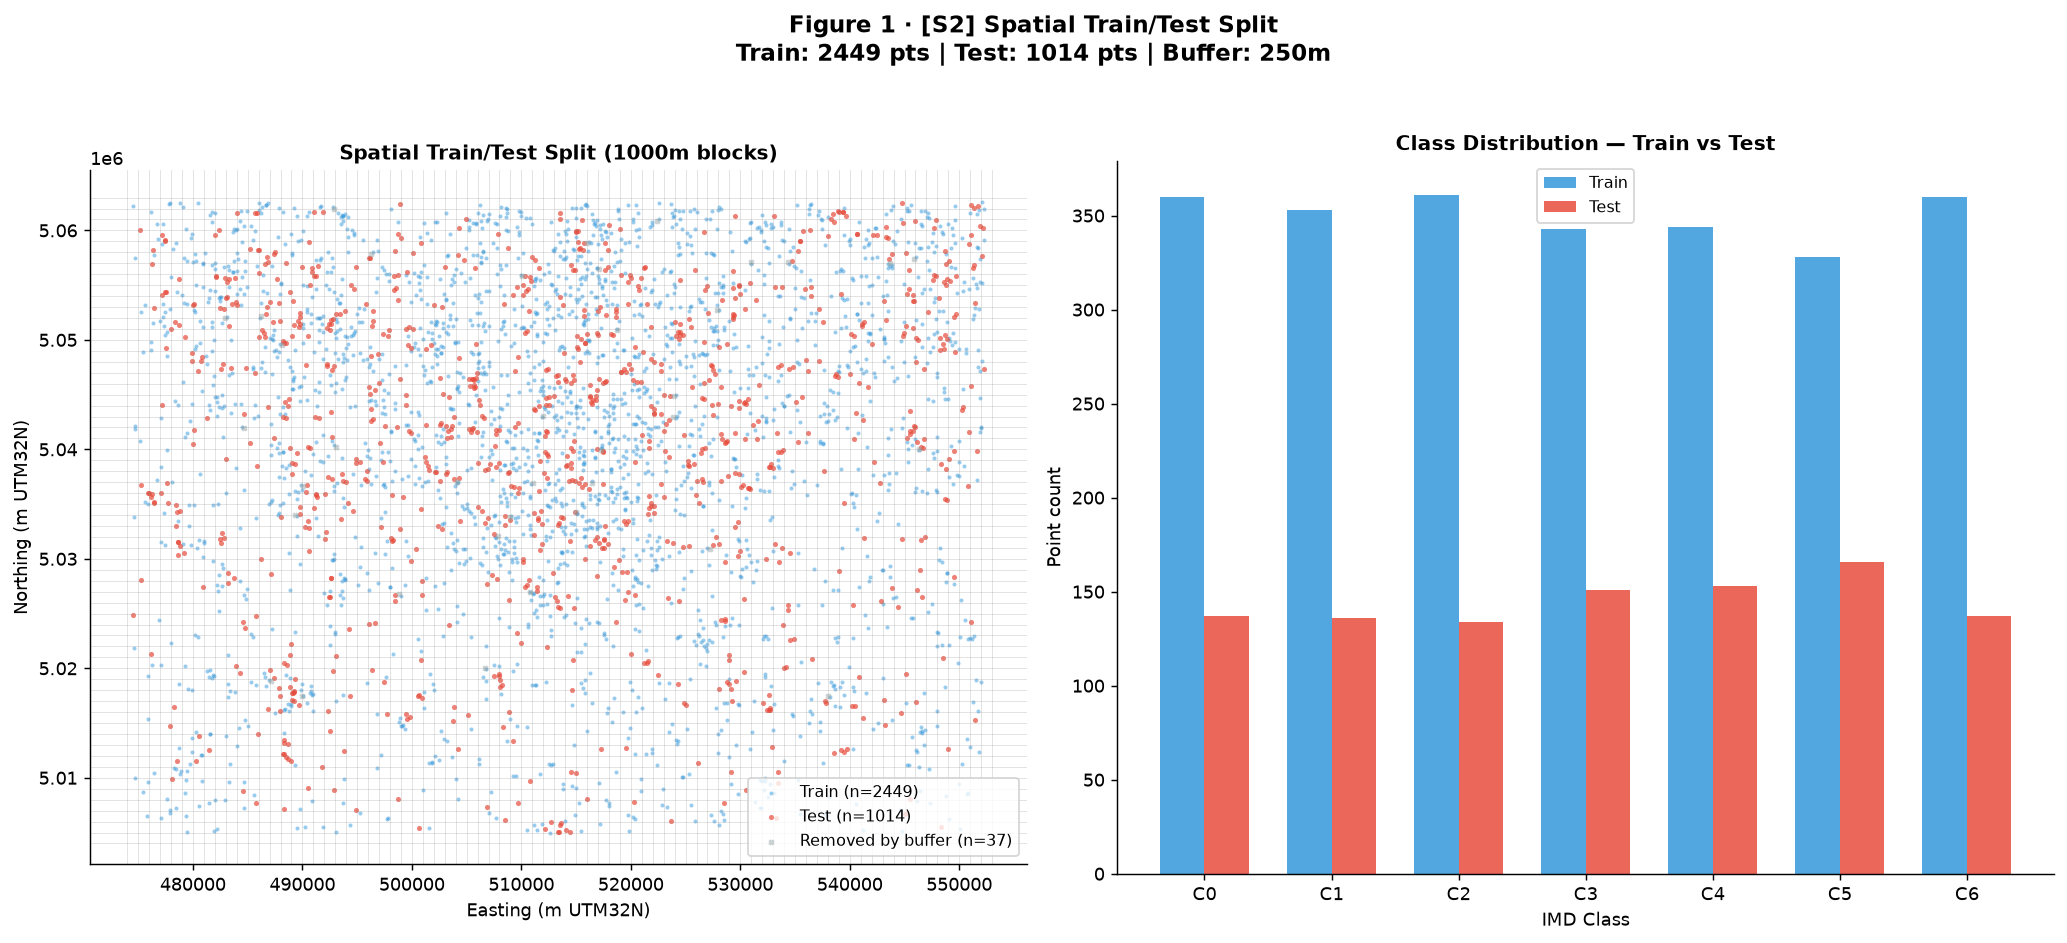

Figure 1 saved.


In [7]:
# Figure 1 -- Spatial train/test split visualisation
fold_colors_tt = {'train': '#3498db', 'test': '#e74c3c', 'removed': '#95a5a6'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: block assignment
ax = axes[0]
# colour each block
block_ids_train = assign_blocks(coords_train, SPLIT_BLOCK_M)
block_ids_test  = assign_blocks(coords_test,  SPLIT_BLOCK_M)
# removed_coords is defined in the split cell above

ax.scatter(coords_train[:, 0], coords_train[:, 1],
           c=fold_colors_tt['train'], s=5, alpha=0.5, linewidths=0, label=f'Train (n={len(train_idx)})')
ax.scatter(coords_test[:, 0], coords_test[:, 1],
           c=fold_colors_tt['test'], s=8, alpha=0.7, linewidths=0, label=f'Test (n={len(test_idx)})')
if len(removed_coords):
    ax.scatter(removed_coords[:, 0], removed_coords[:, 1],
               c=fold_colors_tt['removed'], s=6, alpha=0.5, marker='x',
               label=f'Removed by buffer (n={len(removed_coords)})')

# Draw 1km grid
x0, x1 = coords_all[:,0].min(), coords_all[:,0].max()
y0, y1 = coords_all[:,1].min(), coords_all[:,1].max()
for x in np.arange(x0 // SPLIT_BLOCK_M * SPLIT_BLOCK_M, x1 + SPLIT_BLOCK_M, SPLIT_BLOCK_M):
    ax.axvline(x, color='grey', lw=0.3, alpha=0.4)
for y_val in np.arange(y0 // SPLIT_BLOCK_M * SPLIT_BLOCK_M, y1 + SPLIT_BLOCK_M, SPLIT_BLOCK_M):
    ax.axhline(y_val, color='grey', lw=0.3, alpha=0.4)

ax.set_title(f'Spatial Train/Test Split ({SPLIT_BLOCK_M}m blocks)', fontweight='bold')
ax.set_xlabel('Easting (m UTM32N)'); ax.set_ylabel('Northing (m UTM32N)')
ax.set_aspect('equal')
ax.legend(fontsize=9)

# Right: class distribution comparison
ax = axes[1]
x_cls = np.arange(N_CLASSES)
w = 0.35
train_counts = [int((gdf_train['IMD_class']==c).sum()) for c in range(N_CLASSES)]
test_counts  = [int((gdf_test['IMD_class']==c).sum())  for c in range(N_CLASSES)]
ax.bar(x_cls - w/2, train_counts, w, color=fold_colors_tt['train'], alpha=0.85, label='Train')
ax.bar(x_cls + w/2, test_counts,  w, color=fold_colors_tt['test'],  alpha=0.85, label='Test')
ax.set_xticks(x_cls)
ax.set_xticklabels([f'C{c}' for c in range(N_CLASSES)])
ax.set_xlabel('IMD Class'); ax.set_ylabel('Point count')
ax.set_title('Class Distribution — Train vs Test', fontweight='bold')
ax.legend(fontsize=9)

fig.suptitle(f'Figure 1 · [S2] Spatial Train/Test Split\n' +
             f'Train: {len(train_idx)} pts | Test: {len(test_idx)} pts | Buffer: {BUFFER_M}m',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig01_spatial_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


---
## Cell 6 · Hyperparameter tuning (spatial block CV on training set only)

In [8]:
# ── Hyperparameter tuning with 5-fold spatial block CV (training set only) ────
# For each model, RandomizedSearchCV uses spatial block folds of the TRAINING set.
# Three block sizes tested; best block size selected by lowest spatial CV RMSE.

spatial_folds_tune = {}
for bs in BLOCK_SIZES:
    bids = assign_blocks(coords_train, bs)
    pf, _ = blocks_to_folds(bids, N_FOLDS, RANDOM_STATE)
    spatial_folds_tune[bs] = pf

param_spaces = {
    'RF': {
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4],
        'max_features':      ['sqrt', 'log2', 0.3, 0.5],
        'max_samples':       [None, 0.7, 0.8, 0.9],
    },
    'SVR': {
        'svr__C':       [0.1, 1, 10, 100, 500],
        'svr__epsilon': [0.01, 0.1, 0.5, 1.0],
        'svr__gamma':   ['scale', 'auto', 0.001, 0.01, 0.1],
        'svr__kernel':  ['rbf', 'linear'],
    },
    'MLP': {
        'mlp__hidden_layer_sizes': [(64,), (128,), (64,64), (128,64), (128,128)],
        'mlp__activation':         ['relu', 'tanh'],
        'mlp__alpha':              [0.0001, 0.001, 0.01, 0.1],
        'mlp__learning_rate_init': [0.001, 0.01],
    },
}
base_estimators = {
    'RF':    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
    'SVR':   Pipeline([('scaler', StandardScaler()), ('svr',   SVR())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('mlp', MLPRegressor(
               max_iter=500, random_state=RANDOM_STATE))]),
}
n_iters = {'RF': N_ITER_RF, 'SVR': N_ITER_SVR, 'MLP': N_ITER_MLP}

tuned_models         = {}
best_block_per_model = {}
tune_rows            = []

for name in ['RF', 'SVR', 'MLP']:
    print(f'\n{"="*55}')
    print(f'  {name} -- tuning on TRAINING set ({N_FOLDS}-fold spatial CV)')
    print(f'{"="*55}')
    model_best_rmse   = np.inf
    model_best_search = None
    model_best_block  = None

    for bs in BLOCK_SIZES:
        label     = f'{bs}m'
        cv_splits = make_spatial_splits(spatial_folds_tune[bs], N_FOLDS)

        print(f'  {label} ... ', end='', flush=True)
        t0     = time.time()
        search = RandomizedSearchCV(
            estimator           = base_estimators[name],
            param_distributions = param_spaces[name],
            n_iter              = n_iters[name],
            cv                  = cv_splits,
            scoring             = 'neg_root_mean_squared_error',
            n_jobs              = N_JOBS,
            random_state        = RANDOM_STATE,
            refit               = True
        )
        search.fit(X_train, y_train)
        cv_rmse = -search.best_score_
        cv_std  = search.cv_results_['std_test_score'][search.best_index_]
        print(f'{time.time()-t0:.1f}s | CV RMSE={cv_rmse:.3f} ± {cv_std:.3f}')
        print(f'          best params: {search.best_params_}')

        tune_rows.append({'Model': name, 'Block': label,
                           'CV_RMSE': round(cv_rmse, 3),
                           'CV_std':  round(cv_std, 3),
                           'Best_params': str(search.best_params_)})

        if cv_rmse < model_best_rmse:
            model_best_rmse   = cv_rmse
            model_best_search = search
            model_best_block  = label

    tuned_models[name]         = model_best_search.best_estimator_
    best_block_per_model[name] = model_best_block
    print(f'  => Best block for {name}: {model_best_block}  CV RMSE={model_best_rmse:.3f}')

tune_df = pd.DataFrame(tune_rows)
tune_df.to_csv(f'{OUTPUT_DIR}/hyperparameter_tuning.csv', index=False)

print('\n' + '=='*28)
print('  TUNING SUMMARY')
print('=='*28) 
for name in tuned_models:
    b    = best_block_per_model[name]
    row  = tune_df[(tune_df['Model']==name) & (tune_df['Block']==b)].iloc[0]
    print(f'  {name:<8}: best block={b}  CV RMSE={row["CV_RMSE"]:.3f} ± {row["CV_std"]:.3f}')
print('=='*28)
print('\nHyperparameter tuning complete.')



  RF -- tuning on TRAINING set (5-fold spatial CV)
  500m ... 224.8s | CV RMSE=11.094 ± 0.398
          best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 0.9, 'max_features': 0.5, 'max_depth': 30}
  1000m ... 223.0s | CV RMSE=11.128 ± 0.838
          best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 0.8, 'max_features': 0.5, 'max_depth': 20}
  2000m ... 222.6s | CV RMSE=11.211 ± 0.488
          best params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_samples': None, 'max_features': 0.5, 'max_depth': None}
  => Best block for RF: 500m  CV RMSE=11.094

  SVR -- tuning on TRAINING set (5-fold spatial CV)
  500m ... 78.4s | CV RMSE=10.849 ± 0.546
          best params: {'svr__kernel': 'rbf', 'svr__gamma': 0.1, 'svr__epsilon': 1.0, 'svr__C': 100}
  1000m ... 68.6s | CV RMSE=10.898 ± 0.687
          best params: {'svr__kernel': 'rbf', 'svr__gamma': 0.1, 'svr__epsilon'

---
## Cell 7 · Spatial CV evaluation on training set

In [9]:
# ── Spatial CV evaluation on training set (quantify autocorrelation inflation) ─
# This mirrors the design in 01b but operates only on the training set.
# Gives honest CV estimates; test set still untouched.

def run_spatial_cv(model_template, X, y, coords,
                   point_folds, n_folds, buffer_m, is_spatial):
    rows = []
    for fold in range(n_folds):
        tr = point_folds != fold
        te = point_folds == fold
        Xtr, ytr = X[tr], y[tr]
        Xte, yte = X[te], y[te]

        if is_spatial and buffer_m > 0:
            keep = apply_buffer(coords[tr], coords[te], buffer_m)
            Xte, yte = Xte[keep], yte[keep]
            n_removed = (~keep).sum()
        else:
            n_removed = 0

        if len(yte) < 10:
            continue

        m = clone(model_template)
        m.fit(Xtr, ytr)
        yp = np.clip(m.predict(Xte), 0, 100)

        rows.append({
            'fold':      fold,
            'n_train':   int(Xtr.shape[0]),
            'n_test':    int(len(yte)),
            'n_removed': int(n_removed),
            'pct_rem':   round(100 * n_removed / max(te.sum(), 1), 1),
            'RMSE':      float(np.sqrt(mean_squared_error(yte, yp))),
            'MAE':       float(mean_absolute_error(yte, yp)),
            'R2':        float(r2_score(yte, yp)),
            'Bias':      float(np.mean(yte - yp)),
        })
    return pd.DataFrame(rows)

# Pre-compute outer evaluation folds (on training set only)
random_folds_tr = np.zeros(len(X_train), dtype=int)
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for fi, (_, tidx) in enumerate(kf.split(X_train)):
    random_folds_tr[tidx] = fi

spatial_folds_eval = {}
for bs in BLOCK_SIZES:
    bids = assign_blocks(coords_train, bs)
    pf, _ = blocks_to_folds(bids, N_FOLDS, RANDOM_STATE)
    spatial_folds_eval[bs] = pf
    n_blocks = len(np.unique(bids))
    counts   = [int((pf==f).sum()) for f in range(N_FOLDS)]
    print(f'{bs}m: {n_blocks} blocks | pts/fold: {counts}')

all_results = {}
total = len(tuned_models) * (1 + len(BLOCK_SIZES))
run_i = 0

for name, model in tuned_models.items():
    run_i += 1
    print(f'\n[{run_i}/{total}] {name} x Random (training set CV)')
    t0 = time.time()
    df = run_spatial_cv(model, X_train, y_train, coords_train,
                        random_folds_tr, N_FOLDS, 0, is_spatial=False)
    print(f'  {time.time()-t0:.1f}s | RMSE: {df["RMSE"].mean():.2f} +/- {df["RMSE"].std():.2f}')
    all_results[(name, 'Random')] = df

    for bs in BLOCK_SIZES:
        run_i += 1
        label = f'{bs}m'
        print(f'[{run_i}/{total}] {name} x {label} (buffer={BUFFER_M}m)')
        t0 = time.time()
        df = run_spatial_cv(model, X_train, y_train, coords_train,
                            spatial_folds_eval[bs], N_FOLDS, BUFFER_M, is_spatial=True)
        print(f'  {time.time()-t0:.1f}s | RMSE: {df["RMSE"].mean():.2f} +/- {df["RMSE"].std():.2f} | ' +
              f'buffer removed: {df["pct_rem"].mean():.1f}%')
        all_results[(name, label)] = df

print(f'\nAll {total} CV runs complete.')


500m: 2079 blocks | pts/fold: [490, 488, 492, 486, 493]
1000m: 1478 blocks | pts/fold: [497, 472, 489, 495, 496]
2000m: 839 blocks | pts/fold: [510, 500, 505, 445, 489]

[1/12] RF x Random (training set CV)
  13.0s | RMSE: 11.12 +/- 0.80
[2/12] RF x 500m (buffer=250m)
  11.5s | RMSE: 11.15 +/- 0.48 | buffer removed: 6.2%
[3/12] RF x 1000m (buffer=250m)
  11.6s | RMSE: 11.24 +/- 0.96 | buffer removed: 3.2%
[4/12] RF x 2000m (buffer=250m)
  11.6s | RMSE: 11.27 +/- 0.68 | buffer removed: 2.0%

[5/12] SVR x Random (training set CV)
  1.0s | RMSE: 10.81 +/- 0.92
[6/12] SVR x 500m (buffer=250m)
  0.9s | RMSE: 10.93 +/- 0.67 | buffer removed: 6.2%
[7/12] SVR x 1000m (buffer=250m)
  1.0s | RMSE: 10.99 +/- 0.79 | buffer removed: 3.2%
[8/12] SVR x 2000m (buffer=250m)
  1.0s | RMSE: 10.93 +/- 0.55 | buffer removed: 2.0%

[9/12] MLP x Random (training set CV)
  27.1s | RMSE: 10.56 +/- 0.71
[10/12] MLP x 500m (buffer=250m)
  31.8s | RMSE: 10.65 +/- 0.66 | buffer removed: 6.2%
[11/12] MLP x 1000m (b

## Test 5 times repeating the folding and then see the mean and stdev

In [10]:
from tqdm import tqdm

N_REPEATS = 5

def run_spatial_cv_repeated(model_template, X, y, coords,
                             block_size, n_folds, buffer_m, is_spatial, n_repeats):
    all_rows = []
    for rep in tqdm(range(n_repeats), desc=f'{"Spatial" if is_spatial else "Random"} {block_size or ""}m', leave=False):
        if is_spatial:
            bids = assign_blocks(coords, block_size)
            pf, _ = blocks_to_folds(bids, n_folds, seed=RANDOM_STATE + rep)
        else:
            pf = np.zeros(len(X), dtype=int)
            kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE + rep)
            for fi, (_, tidx) in enumerate(kf.split(X)):
                pf[tidx] = fi

        df = run_spatial_cv(model_template, X, y, coords, pf, n_folds, buffer_m, is_spatial)
        df['repeat'] = rep
        all_rows.append(df)

    return pd.concat(all_rows, ignore_index=True)

In [11]:
for name, model in tqdm(tuned_models.items(), desc='Models'):
    for bs_label, bs, spatial in (
        [('Random', None, False)] + [(f'{bs}m', bs, True) for bs in BLOCK_SIZES]
    ):
        tqdm.write(f'  {name} x {bs_label}')
        df = run_spatial_cv_repeated(
            model, X_train, y_train, coords_train,
            block_size=bs, n_folds=N_FOLDS,
            buffer_m=BUFFER_M if spatial else 0,
            is_spatial=spatial, n_repeats=N_REPEATS
        )
        all_results[(name, bs_label)] = df

Models:   0%|          | 0/3 [00:00<?, ?it/s]

  RF x Random


Models:   0%|          | 0/3 [01:00<?, ?it/s]

  RF x 500m


Models:   0%|          | 0/3 [01:57<?, ?it/s]

...

Models:  67%|██████▋   | 2/3 [09:12<01:48, 108.16s/it]

  MLP x 1000m


Models:  67%|██████▋   | 2/3 [12:07<01:48, 108.16s/it]

  MLP x 2000m


Models: 100%|██████████| 3/3 [14:56<00:00, 298.86s/it]


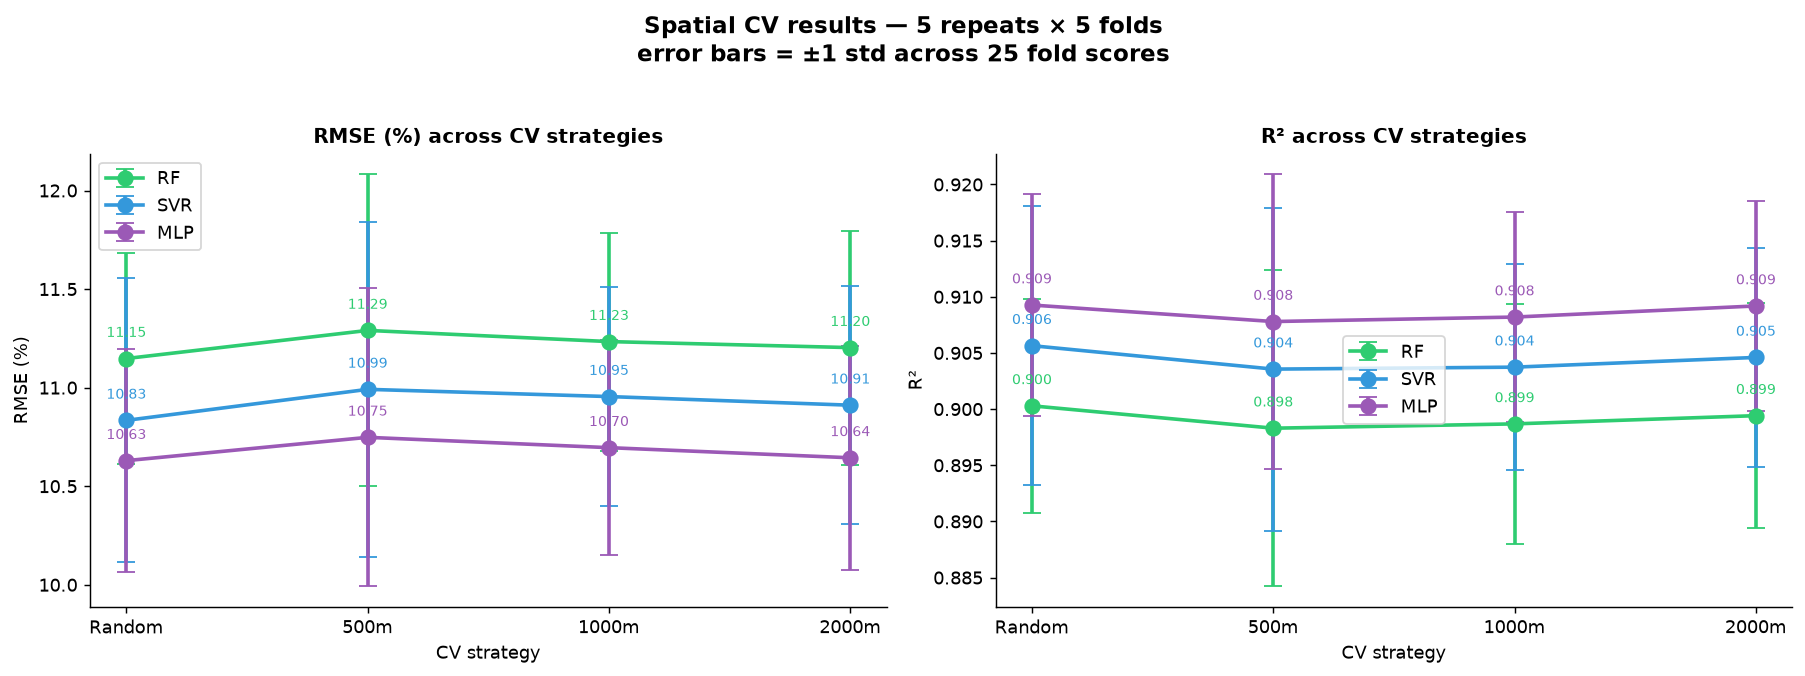

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, ylabel in [('RMSE', axes[0], 'RMSE (%)'), ('R2', axes[1], 'R²')]:
    for name in tuned_models:
        means = [all_results[(name, l)][metric].mean() for l in CV_LABELS]
        stds  = [all_results[(name, l)][metric].std()  for l in CV_LABELS]
        ax.errorbar(range(len(CV_LABELS)), means, yerr=stds,
                    fmt='o-', color=MODEL_COLORS[name], lw=2, ms=8,
                    capsize=5, label=name)
        for i, m in enumerate(means):
            ax.annotate(f'{m:.2f}' if metric=='RMSE' else f'{m:.3f}',
                        (i, m), textcoords='offset points',
                        xytext=(0, 12), ha='center', fontsize=8,
                        color=MODEL_COLORS[name])

    ax.set_xticks(range(len(CV_LABELS)))
    ax.set_xticklabels(CV_LABELS)
    ax.set_xlabel('CV strategy')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} across CV strategies', fontweight='bold')
    ax.legend(fontsize=10)

fig.suptitle(f'Spatial CV results — {N_REPEATS} repeats × {N_FOLDS} folds\n'
             f'error bars = ±1 std across {N_REPEATS * N_FOLDS} fold scores',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_repeated_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 8 · Summary table & best model selection

In [13]:
# Summary table
rows = []
for name in tuned_models:
    for label in CV_LABELS:
        df = all_results[(name, label)]
        rows.append({
            'Model':       name,
            'CV_method':   label,
            'RMSE_mean':   round(df['RMSE'].mean(), 2),
            'RMSE_std':    round(df['RMSE'].std(), 2),
            'MAE_mean':    round(df['MAE'].mean(), 2),
            'MAE_std':     round(df['MAE'].std(), 2),
            'R2_mean':     round(df['R2'].mean(), 3),
            'R2_std':      round(df['R2'].std(), 3),
            'Bias_mean':   round(df['Bias'].mean(), 2),
            'Bias_std':    round(df['Bias'].std(), 2),
            'pct_rem_avg': round(df['pct_rem'].mean(), 1),
        })
summary_df = pd.DataFrame(rows)
summary_df.to_csv(f'{OUTPUT_DIR}/spatial_cv_summary.csv', index=False)

print('=='*35)
print(f'  SPATIAL CV (training set) -- buffer={BUFFER_M}m, {N_FOLDS}-fold')
print('=='*35)
print(summary_df.to_string(index=False))
print('=='*35)

# Best model overall
spatial_labels = [f'{bs}m' for bs in BLOCK_SIZES]
best_rmse = np.inf
BEST_MODEL_NAME  = None
BEST_BLOCK_LABEL = None
for name in tuned_models:
    label = best_block_per_model[name]
    rmse  = all_results[(name, label)]['RMSE'].mean()
    if rmse < best_rmse:
        best_rmse        = rmse
        BEST_MODEL_NAME  = name
        BEST_BLOCK_LABEL = label

BEST_MODEL = tuned_models[BEST_MODEL_NAME]
print(f'\n* Overall best: {BEST_MODEL_NAME} @ {BEST_BLOCK_LABEL}  RMSE={best_rmse:.3f}%')
print(f'  -> GEE raster + holdout evaluation')


  SPATIAL CV (training set) -- buffer=250m, 5-fold
Model CV_method  RMSE_mean  RMSE_std  MAE_mean  MAE_std  R2_mean  R2_std  Bias_mean  Bias_std  pct_rem_avg
   RF    Random      11.15      0.54      7.80     0.23    0.900   0.009       0.11      0.63          0.0
   RF      500m      11.29      0.79      7.86     0.39    0.898   0.014      -0.05      0.71          6.5
   RF     1000m      11.23      0.55      7.84     0.31    0.899   0.011       0.03      0.54          3.2
   RF     2000m      11.20      0.59      7.80     0.34    0.899   0.010       0.04      0.52          1.8
  SVR    Random      10.83      0.72      7.25     0.34    0.906   0.012      -1.03      0.47          0.0
  SVR      500m      10.99      0.85      7.35     0.35    0.904   0.014      -1.17      0.70          6.5
  SVR     1000m      10.95      0.55      7.34     0.26    0.904   0.009      -1.06      0.46          3.2
  SVR     2000m      10.91      0.60      7.28     0.34    0.905   0.010      -1.05      0.53

---
## Cell 9 · Figure 2 — CV fold maps

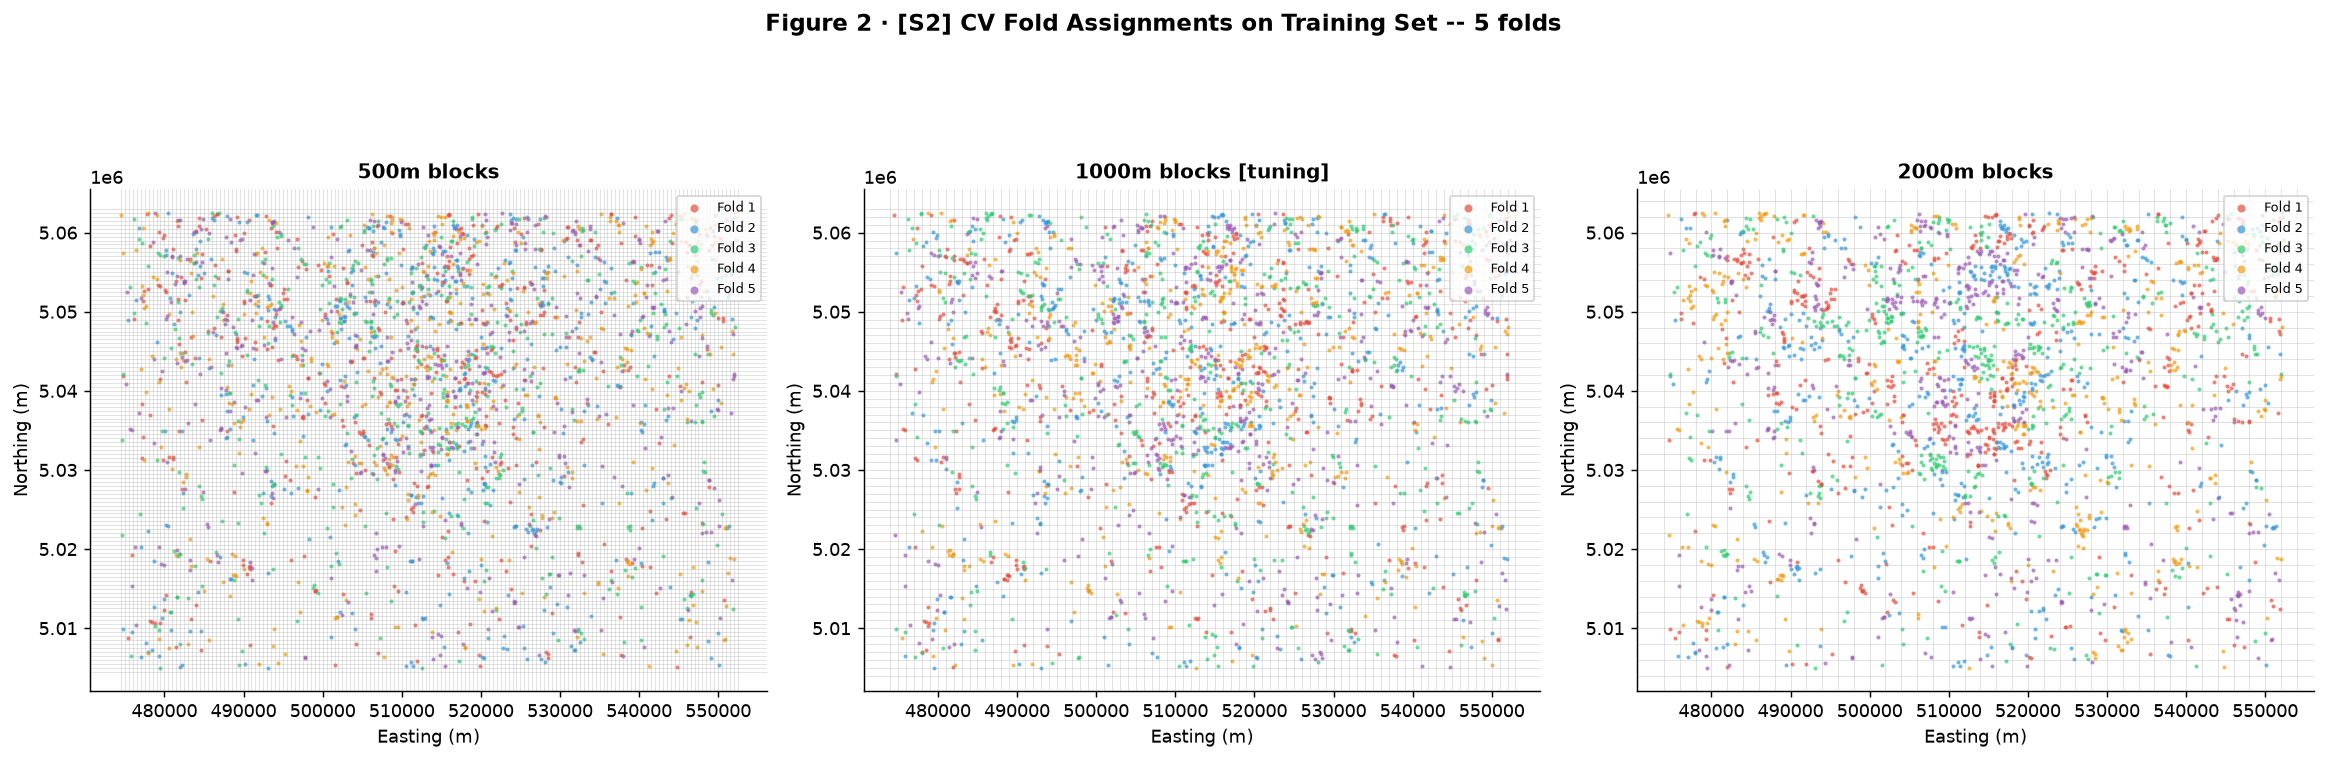

Figure 2 saved.


In [14]:
# Figure 2 -- CV fold maps on training set
fold_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, bs in zip(axes, BLOCK_SIZES):
    pf = spatial_folds_eval[bs]
    for fold in range(N_FOLDS):
        m = pf == fold
        ax.scatter(coords_train[m, 0], coords_train[m, 1],
                   c=fold_colors[fold], s=5, alpha=0.7,
                   label=f'Fold {fold+1}', linewidths=0)
    x0, x1 = coords_train[:,0].min(), coords_train[:,0].max()
    y0, y1 = coords_train[:,1].min(), coords_train[:,1].max()
    for x in np.arange(x0 // bs * bs, x1 + bs, bs):
        ax.axvline(x, color='grey', lw=0.3, alpha=0.4)
    for y_val in np.arange(y0 // bs * bs, y1 + bs, bs):
        ax.axhline(y_val, color='grey', lw=0.3, alpha=0.4)
    marker = ' [tuning]' if f'{bs}m' == best_block_per_model.get(BEST_MODEL_NAME, '') else ''
    ax.set_title(f'{bs}m blocks{marker}', fontweight='bold')
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=7, markerscale=2)

fig.suptitle(f'Figure 2 · [S2] CV Fold Assignments on Training Set -- {N_FOLDS} folds',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig02_cv_folds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')


---
## Cell 10 · Figure 3 — RMSE & R² degradation curves

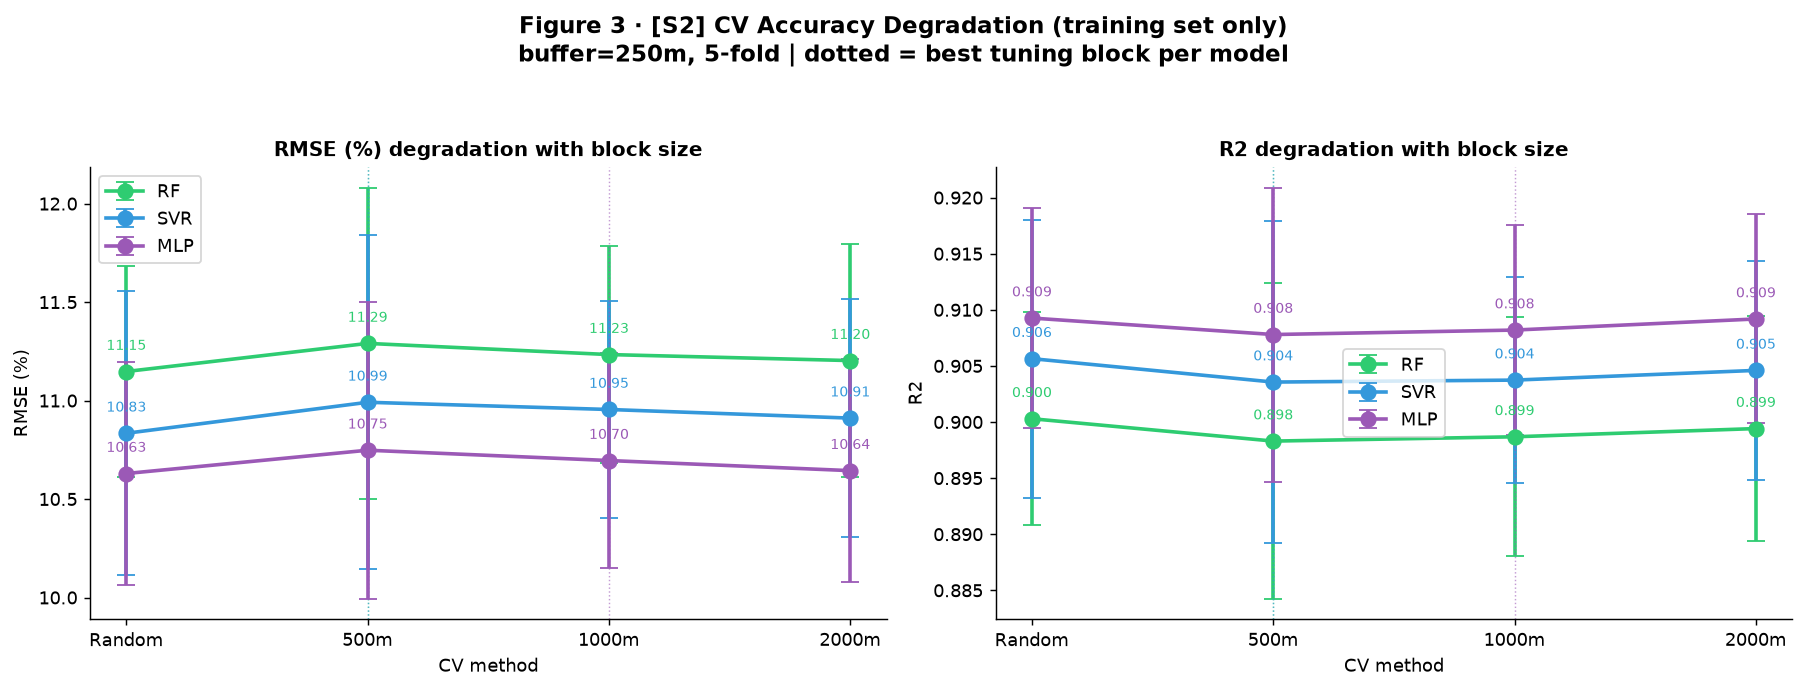

Figure 3 saved.


In [15]:
# Figure 3 -- RMSE & R2 degradation curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax, ylabel in [('RMSE', axes[0], 'RMSE (%)'), ('R2', axes[1], 'R2')]:
    for name in tuned_models:
        means = [all_results[(name, l)][metric].mean() for l in CV_LABELS]
        stds  = [all_results[(name, l)][metric].std()  for l in CV_LABELS]
        ax.errorbar(range(len(CV_LABELS)), means, yerr=stds,
                    fmt='o-', color=MODEL_COLORS[name], lw=2, ms=8, capsize=5, label=name)
        for i, m_val in enumerate(means):
            ax.annotate(f'{m_val:.2f}' if metric=='RMSE' else f'{m_val:.3f}',
                        (i, m_val), textcoords='offset points',
                        xytext=(0, 12), ha='center', fontsize=8, color=MODEL_COLORS[name])
        best_b = best_block_per_model[name]
        if best_b in CV_LABELS:
            ax.axvline(CV_LABELS.index(best_b), color=MODEL_COLORS[name],
                       lw=0.8, ls=':', alpha=0.6)
    ax.set_xticks(range(len(CV_LABELS)))
    ax.set_xticklabels(CV_LABELS)
    ax.set_xlabel('CV method'); ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} degradation with block size', fontweight='bold')
    ax.legend(fontsize=10)

fig.suptitle(f'Figure 3 · [S2] CV Accuracy Degradation (training set only)\n' +
             f'buffer={BUFFER_M}m, {N_FOLDS}-fold | dotted = best tuning block per model',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig03_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')


---
## Cell 11 · Figure 4 — Per-fold RMSE boxplots

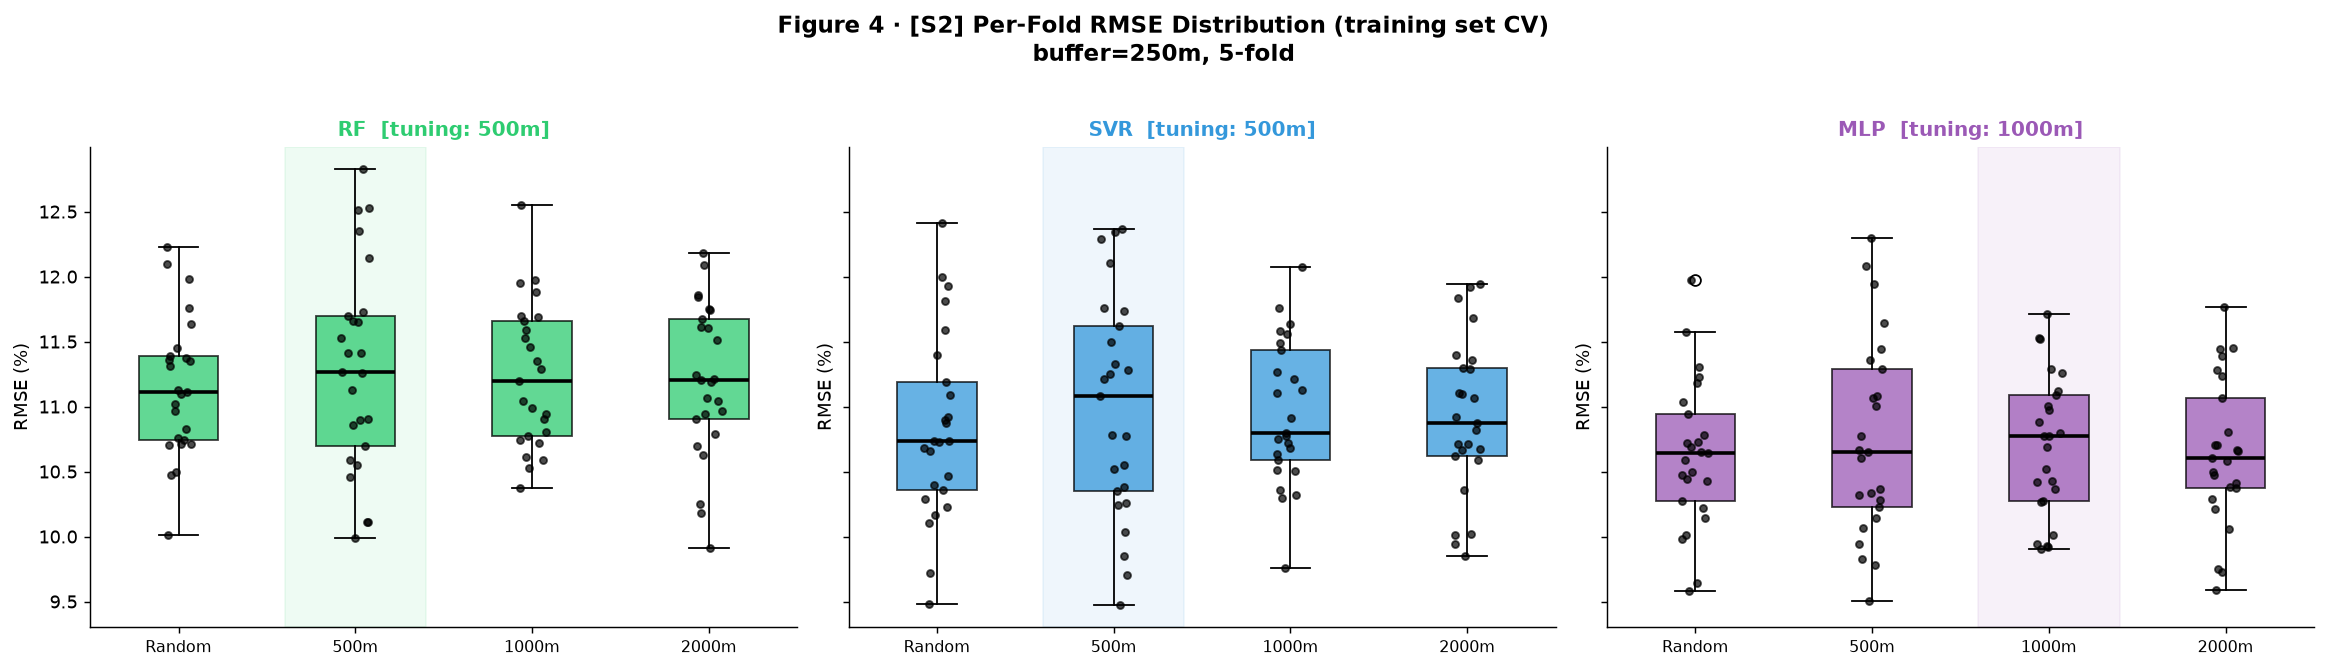

Figure 4 saved.


In [16]:
# Figure 4 -- Per-fold RMSE boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, name in zip(axes, tuned_models):
    data = [all_results[(name, l)]['RMSE'].values for l in CV_LABELS]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    whiskerprops={'lw': 1}, capprops={'lw': 1})
    for patch in bp['boxes']:
        patch.set_facecolor(MODEL_COLORS[name]); patch.set_alpha(0.75)
    for i, d in enumerate(data, start=1):
        ax.scatter(np.full(len(d), i) + np.random.uniform(-0.08, 0.08, len(d)),
                   d, c='black', s=15, zorder=5, alpha=0.7)
    best_b = best_block_per_model[name]
    if best_b in CV_LABELS:
        bi = CV_LABELS.index(best_b) + 1
        ax.axvspan(bi-0.4, bi+0.4, alpha=0.08, color=MODEL_COLORS[name])
    ax.set_xticks(range(1, len(CV_LABELS)+1))
    ax.set_xticklabels(CV_LABELS, fontsize=9)
    ax.set_ylabel('RMSE (%)')
    ax.set_title(f'{name}  [tuning: {best_block_per_model[name]}]',
                 fontweight='bold', fontsize=11, color=MODEL_COLORS[name])

fig.suptitle(f'Figure 4 · [S2] Per-Fold RMSE Distribution (training set CV)\n' +
             f'buffer={BUFFER_M}m, {N_FOLDS}-fold',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig04_rmse_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')


---
## Cell 12 · Figure 5 — All metrics grouped bar chart

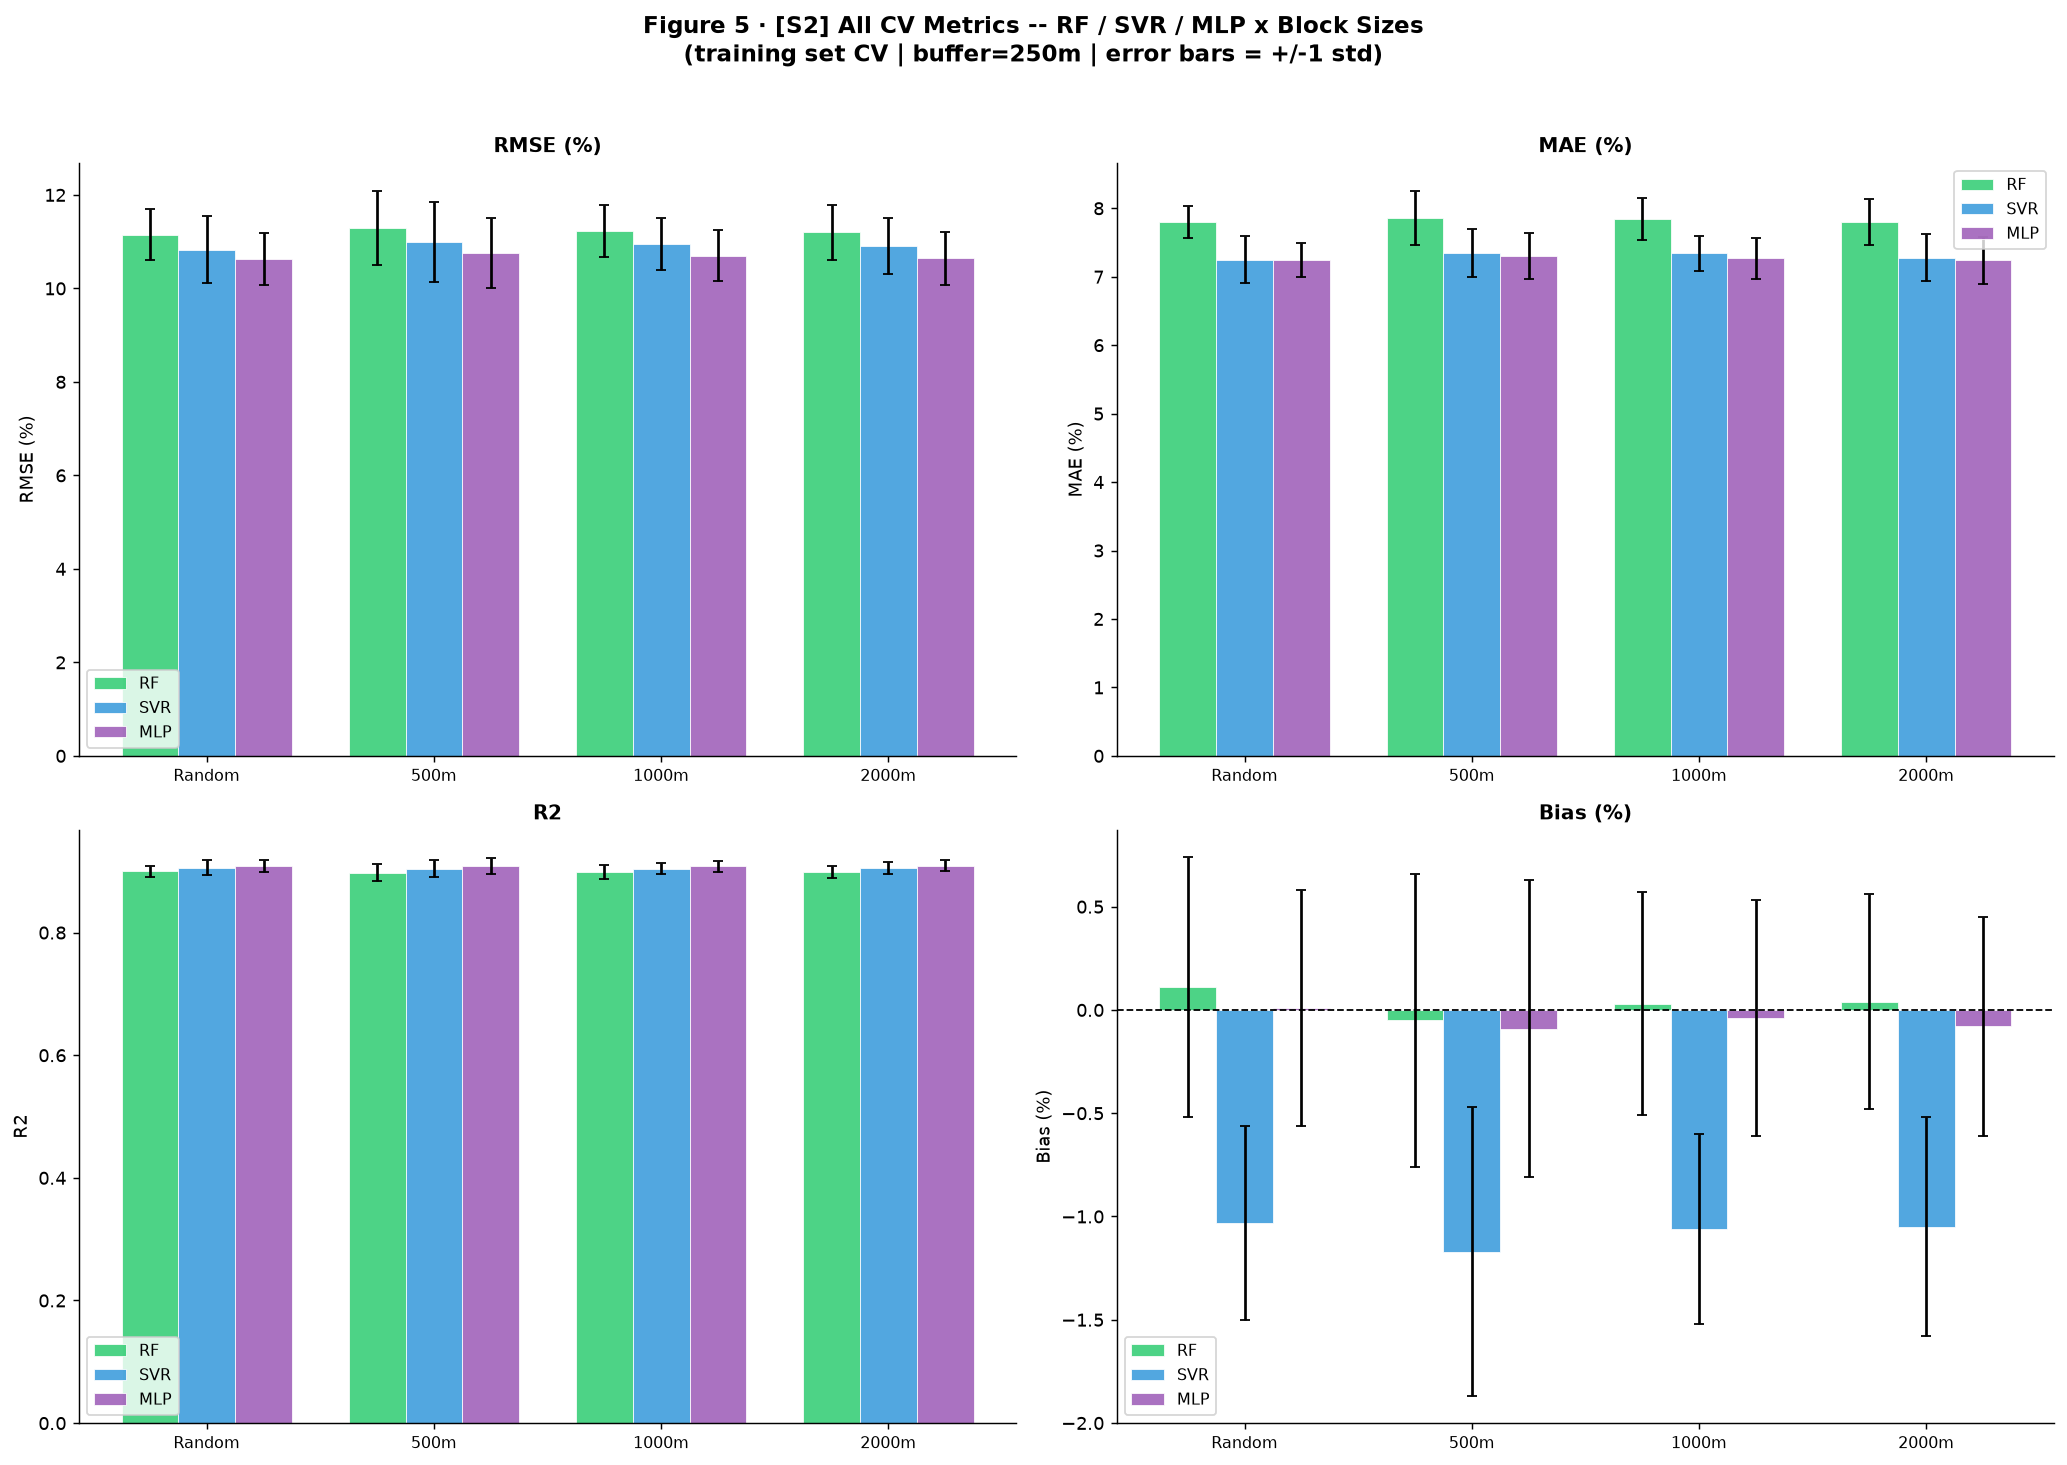

Figure 5 saved.


In [17]:
# Figure 5 -- All metrics grouped bar chart
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()
metrics_info = [
    ('RMSE_mean', 'RMSE_std', 'RMSE (%)'),
    ('MAE_mean',  'MAE_std',  'MAE (%)'),
    ('R2_mean',   'R2_std',   'R2'),
    ('Bias_mean', 'Bias_std', 'Bias (%)'),
]
model_names = list(tuned_models.keys())
n_models = len(model_names)
x = np.arange(len(CV_LABELS))
width = 0.25
offsets = {m: (i - n_models//2) * width for i, m in enumerate(model_names)}

for ax, (mean_col, std_col, ylabel) in zip(axes, metrics_info):
    for name in model_names:
        sub  = summary_df[summary_df['Model'] == name].set_index('CV_method')
        vals = [sub.loc[l, mean_col] for l in CV_LABELS]
        errs = [sub.loc[l, std_col]  for l in CV_LABELS]
        ax.bar(x + offsets[name], vals, width,
               color=MODEL_COLORS[name], alpha=0.85,
               label=name, edgecolor='white', lw=0.5,
               yerr=errs, capsize=3)
    if mean_col == 'Bias_mean':
        ax.axhline(0, color='black', lw=1, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(CV_LABELS, fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(ylabel, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle(f'Figure 5 · [S2] All CV Metrics -- RF / SVR / MLP x Block Sizes\n' +
             f'(training set CV | buffer={BUFFER_M}m | error bars = +/-1 std)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig05_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')


---
## Cell 13 · Figure 6 — Spatial autocorrelation inflation heatmap

   SPATIAL AUTOCORRELATION INFLATION (training set CV)
   Buffer=250m | Folds=5 | Reference: Random CV

  RF  |  Random: RMSE=11.15%  R2=0.900  |  tuning block=500m
    500m  : RMSE=11.29%  R2=0.898  (+0.14pp, +1.3%) <- tuning block
    1000m : RMSE=11.23%  R2=0.899  (+0.09pp, +0.8%)
    2000m : RMSE=11.20%  R2=0.899  (+0.06pp, +0.5%)

  SVR  |  Random: RMSE=10.83%  R2=0.906  |  tuning block=500m
    500m  : RMSE=10.99%  R2=0.904  (+0.16pp, +1.5%) <- tuning block
    1000m : RMSE=10.95%  R2=0.904  (+0.12pp, +1.1%)
    2000m : RMSE=10.91%  R2=0.905  (+0.08pp, +0.7%)

  MLP  |  Random: RMSE=10.63%  R2=0.909  |  tuning block=1000m
    500m  : RMSE=10.75%  R2=0.908  (+0.12pp, +1.1%)
    1000m : RMSE=10.70%  R2=0.908  (+0.07pp, +0.6%) <- tuning block
    2000m : RMSE=10.64%  R2=0.909  (+0.01pp, +0.1%)


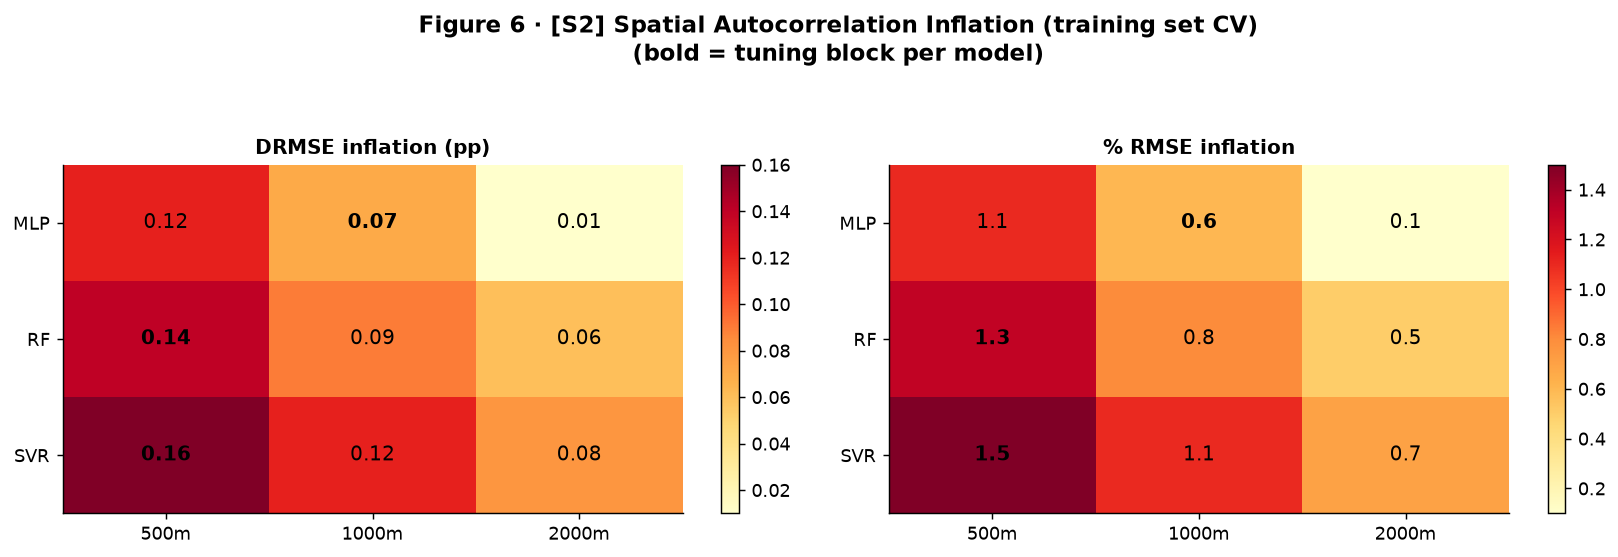

Figure 6 saved.


In [18]:
# Figure 6 -- Spatial autocorrelation inflation heatmap
print('='*65)
print('   SPATIAL AUTOCORRELATION INFLATION (training set CV)')
print(f'   Buffer={BUFFER_M}m | Folds={N_FOLDS} | Reference: Random CV')
print('='*65)

inflation_rows = []
for name in tuned_models:
    rnd_rmse = all_results[(name, 'Random')]['RMSE'].mean()
    rnd_r2   = all_results[(name, 'Random')]['R2'].mean()
    best_b   = best_block_per_model[name]
    print(f'\n  {name}  |  Random: RMSE={rnd_rmse:.2f}%  R2={rnd_r2:.3f}  |  tuning block={best_b}')
    for bs in BLOCK_SIZES:
        label   = f'{bs}m'
        sp_rmse = all_results[(name, label)]['RMSE'].mean()
        sp_r2   = all_results[(name, label)]['R2'].mean()
        diff    = sp_rmse - rnd_rmse
        pct     = 100 * diff / rnd_rmse
        marker  = ' <- tuning block' if label == best_b else ''
        print(f'    {label:<6}: RMSE={sp_rmse:.2f}%  R2={sp_r2:.3f}  ' +
              f'({diff:+.2f}pp, {pct:+.1f}%){marker}')
        inflation_rows.append({
            'Model': name, 'Block': label,
            'Random_RMSE': round(rnd_rmse, 2), 'Spatial_RMSE': round(sp_rmse, 2),
            'RMSE_diff': round(diff, 2), 'Pct_inflation': round(pct, 1),
            'Tuning_block': best_b,
        })

infl_df = pd.DataFrame(inflation_rows)
infl_df.to_csv(f'{OUTPUT_DIR}/inflation_analysis.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title, fmt in [
    (axes[0], 'RMSE_diff',     'DRMSE inflation (pp)', '.2f'),
    (axes[1], 'Pct_inflation', '% RMSE inflation',     '.1f'),
]:
    pivot = infl_df.pivot(index='Model', columns='Block', values=col)
    pivot = pivot[[f'{bs}m' for bs in BLOCK_SIZES]]
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(BLOCK_SIZES)))
    ax.set_xticklabels([f'{bs}m' for bs in BLOCK_SIZES])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            is_best = (f'{BLOCK_SIZES[j]}m' == best_block_per_model[pivot.index[i]])
            ax.text(j, i, f'{pivot.values[i,j]:{fmt}}',
                    ha='center', va='center', fontsize=11,
                    fontweight='bold' if is_best else 'normal')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax)

fig.suptitle('Figure 6 · [S2] Spatial Autocorrelation Inflation (training set CV)\n' +
             '(bold = tuning block per model)',
             fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig06_inflation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')


---
## Cell 14 · GEE raster export

Retrain on full training set. Export RF and SVR rasters.
Download GeoTIFFs from Google Drive before Cell 15.

In [ ]:
# ── Save the RF model + metadata for the transferability notebooks ───────────
# This is the LOCAL ARTIFACT SAVE; the next cell does the GEE raster export.
# The two are complementary -- do not merge them.
#
# RF is dumped REGARDLESS of which model won the CV. Notebook 01 does the same
# ("Always save RF separately"), because the Vietnam transferability notebooks
# apply a Random Forest and need one for every predictor variant, not only for
# the runs where RF happened to be best.
#
# This cell was commented out for several runs, which is why outputs_S2_median,
# outputs_S2_stack and outputs_S2_percentile_* each hold only whichever model
# won (cell 35's dump) and no metadata JSON at all.
rf_fitted = clone(tuned_models['RF'])
rf_fitted.fit(X_train, y_train)
joblib.dump(rf_fitted, f'{OUTPUT_DIR}/best_model_RF_S2.joblib')

# Guard: holdout_df is created in the Holdout evaluation cell, which runs LATER
# than this one. On a first top-to-bottom pass it does not exist yet, so fall
# back to None rather than raising. Re-run this cell after the holdout cell to
# backfill the four metrics.
_hd = holdout_df if 'holdout_df' in dir() else None
def _hd_val(col):
    if _hd is not None and 'GEE_RF' in _hd['Model'].values:
        return float(_hd[_hd['Model'] == 'GEE_RF'][col].values[0])
    return None

meta = {
    'predictor':       'Sentinel-2 L2A',
    'collection':      S2_COLLECTION,
    'selected_dates':  SELECTED_DATES,
    'best_model_name': BEST_MODEL_NAME,
    'best_block':      BEST_BLOCK_LABEL,
    'band_names':      band_names,
    'best_params':     {k: str(v) for k, v in rf_fitted.get_params().items()},
    'holdout_rmse':    _hd_val('RMSE'),
    'holdout_mae':     _hd_val('MAE'),
    'holdout_r2':      _hd_val('R2'),
    'holdout_bias':    _hd_val('Bias'),
    # Band names alone cannot identify a run -- a 4-date and a 30-date median
    # are both ['B2'...'B12']. Pin the composite identity so a consumer can
    # assert it loaded the run it thinks it did.
    'method':          COMPOSITE_METHOD,
    'percentiles':     (list(PERCENTILES)
                        if COMPOSITE_METHOD == 'percentile' else None),
}
with open(f'{OUTPUT_DIR}/model_metadata_S2.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved {OUTPUT_DIR}/best_model_RF_S2.joblib')
print(f'Saved {OUTPUT_DIR}/model_metadata_S2.json')
print(f'  method={COMPOSITE_METHOD}  bands={len(band_names)}  '
      f'best={BEST_MODEL_NAME} @ {BEST_BLOCK_LABEL}')
if _hd is None:
    print('  NOTE: holdout metrics are null -- re-run this cell after the '
          'holdout evaluation cell to backfill them.')

In [20]:
# Retrain best model on full training set and export rasters to GEE
best_model_fitted = clone(BEST_MODEL)
best_model_fitted.fit(X_train, y_train)
joblib.dump(best_model_fitted, f'{OUTPUT_DIR}/best_model_{BEST_MODEL_NAME}.joblib')

# Extract SVR pipeline parameters
svr_pipeline = tuned_models['SVR']
svr_scaler = svr_pipeline.named_steps['scaler']
svr_model = svr_pipeline.named_steps['svr']
scaler_mean = svr_scaler.mean_
scaler_scale = svr_scaler.scale_

# Keep exactly the tuned gamma
if svr_model.gamma == 'auto':
    gee_gamma = 1.0 / len(band_names)
elif svr_model.gamma == 'scale':
    X_scaled = svr_scaler.transform(X_train)
    gee_gamma = 1.0 / (len(band_names) * np.var(X_scaled))
else:
    gee_gamma = float(svr_model.gamma)

print("GEE SVR parameters:")
print(" C =", svr_model.C)
print(" gamma =", gee_gamma)
print(" kernel =", svr_model.kernel)
print(" epsilon =", svr_model.epsilon)

# Build GEE FeatureCollections
# RF uses original bands, SVR uses standardized bands
features_rf = []
features_svr = []
scaled_band_names = [b + '_scaled' for b in band_names]

for _, row in gdf_train.iterrows():
    # RF features
    props_rf = {b: float(row[b]) for b in band_names}
    props_rf['IMD'] = float(row['IMD'])
    features_rf.append(ee.Feature(None, props_rf))
    
    # SVR scaled features
    props_svr = {}
    for i, b in enumerate(band_names):
        props_svr[b + '_scaled'] = (float(row[b]) - float(scaler_mean[i])) / float(scaler_scale[i])
    props_svr['IMD'] = float(row['IMD'])
    features_svr.append(ee.Feature(None, props_svr))

train_fc_rf = ee.FeatureCollection(features_rf)
train_fc_svr = ee.FeatureCollection(features_svr)

# Create scaled prediction image for SVR
pred_img_svr = pred_img
for i, b in enumerate(band_names):
    pred_img_svr = pred_img_svr.addBands(
        pred_img.select(b)
        .subtract(float(scaler_mean[i]))
        .divide(float(scaler_scale[i]))
        .rename(b + '_scaled')
    )

# Train GEE models
def train_gee_regressor(model_type):
    if model_type == 'RF':
        params = tuned_models['RF'].get_params()
        clf = ee.Classifier.smileRandomForest(
            numberOfTrees=params.get('n_estimators', 200),
            minLeafPopulation=params.get('min_samples_leaf', 1),
            seed=RANDOM_STATE
        ).setOutputMode('REGRESSION').train(
            features=train_fc_rf,
            classProperty='IMD',
            inputProperties=band_names
        )
    elif model_type == 'SVR':
        clf = ee.Classifier.libsvm(
            svmType='EPSILON_SVR',
            kernelType=svr_model.kernel.upper(),
            cost=float(svr_model.C),
            gamma=float(gee_gamma),
            lossEpsilon=float(svr_model.epsilon)
        ).setOutputMode('REGRESSION').train(
            features=train_fc_svr,
            classProperty='IMD',
            inputProperties=scaled_band_names
        )
    return clf

# Prediction image
def make_pred_image(clf, model_type):
    if model_type == 'SVR':
        img = pred_img_svr.select(scaled_band_names)
    else:
        img = pred_img.select(band_names)
    return (img.classify(clf).rename('IMD_predicted')
            .clip(aoi_geom).updateMask(non_water_mask))

# Export function
def export_drive(image, name):
    task = ee.batch.Export.image.toDrive(
        image=image, description=name, folder='GEE_exports',
        fileNamePrefix=name, region=aoi_geom,
        scale=10, crs='EPSG:32632', maxPixels=1e10
    )
    task.start()
    print(f'Export started: {name}')

# Export RF
print('Training GEE RF...')
prediction_rf = make_pred_image(train_gee_regressor('RF'), 'RF')
export_drive(prediction_rf, 'IMD_predicted_RF_S2_Milan')

# Export SVR
print('Training GEE SVR...')
prediction_svr = make_pred_image(train_gee_regressor('SVR'), 'SVR')
export_drive(prediction_svr, 'IMD_predicted_SVR_S2_Milan')

print(f'\nBest model: {BEST_MODEL_NAME} @ {BEST_BLOCK_LABEL}')
print('Download GeoTIFFs from Google Drive before Cell 15.')

GEE SVR parameters:
 C = 100
 gamma = 0.1
 kernel = rbf
 epsilon = 1.0
Training GEE RF...
Export started: IMD_predicted_RF_S2_Milan
Training GEE SVR...
Export started: IMD_predicted_SVR_S2_Milan

Best model: MLP @ 1000m
Download GeoTIFFs from Google Drive before Cell 15.


---
## Cell 15 · Holdout test set evaluation

Test set touched for the first time here.
GEE rasters sampled at spatial holdout locations.

In [23]:
# ── Holdout test set evaluation -- touched for the first time ─────────────────
def sample_raster_at_points(raster_path, gdf):
    gdf_r = gdf.to_crs('EPSG:32632')
    coords_pts = [(geom.x, geom.y) for geom in gdf_r.geometry]
    with rasterio.open(raster_path) as src:
        vals = np.array([v[0] for v in src.sample(coords_pts)], dtype=float)
        if src.nodata is not None:
            vals[vals == src.nodata] = np.nan
    return vals

# Local sklearn predictions. Also PERSISTED per-point: these 1014 residuals are
# what a paired test across composite methods runs on. The split is imported and
# geometries are bit-identical across methods, so rows align 1:1 by geo_key --
# no GEE raster export needed to compare methods.
local_pred = {}
print('Local sklearn predictions on spatial holdout test set:')
print(f'{"Model":<8} {"RMSE":>8} {"MAE":>8} {"R2":>8} {"Bias":>8}  [tuning block]')
print('-' * 58)
for name, model in tuned_models.items():
    yp = np.clip(model.predict(X_test), 0, 100)
    local_pred[name] = yp
    print(f'  {name:<6}  ' +
          f'RMSE={np.sqrt(mean_squared_error(y_test, yp)):.2f}%  ' +
          f'MAE={mean_absolute_error(y_test, yp):.2f}%  ' +
          f'R2={r2_score(y_test, yp):.3f}  ' +
          f'Bias={np.mean(y_test - yp):+.2f}%  ' +
          f'[{best_block_per_model[name]}]')

# GEE raster evaluation
holdout_results = {}
print(f'\nGEE raster predictions at spatial holdout test locations:')
for label, path in [('GEE_RF', RF_RASTER_PATH), ('GEE_SVR', SVR_RASTER_PATH)]:
    if not os.path.exists(path):
        print(f'  {label}: file not found -- {path}')
        continue
    yp    = np.clip(sample_raster_at_points(path, gdf_test), 0, 100)
    valid = ~np.isnan(yp)
    yt    = y_test[valid]
    yp    = yp[valid]
    metrics = {
        'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':  float(mean_absolute_error(yt, yp)),
        'R2':   float(r2_score(yt, yp)),
        
        'Bias': float(np.mean(yt - yp)),
        
    }
    holdout_results[label] = {'metrics': metrics, 'y_pred': yp, 'y_true': yt,
                               'cls': gdf_test['IMD_class'].values[valid]}
    print(f'  {label}: RMSE={metrics["RMSE"]:.2f}%  MAE={metrics["MAE"]:.2f}%  ' +
          f'R2={metrics["R2"]:.3f}  Bias={metrics["Bias"]:+.2f}%  (valid: {valid.sum()}/{len(y_test)})')

holdout_df = pd.DataFrame([{'Model': k, **v['metrics']} for k, v in holdout_results.items()]).round(3)
holdout_df.to_csv(f'{OUTPUT_DIR}/holdout_test_metrics.csv', index=False)
print('\nHoldout metrics saved.')

# ── Per-point holdout residuals (for cross-method paired comparison) ─────────
_gt = gdf_test.to_crs('EPSG:4326').geometry
resid = pd.DataFrame({
    'lon':    _gt.x.round(7),
    'lat':    _gt.y.round(7),
    'IMD':    y_test,
    'IMD_class': gdf_test['IMD_class'].values,
})
for name, yp in local_pred.items():
    resid[f'pred_{name}'] = yp
    resid[f'err_{name}']  = yp - y_test
resid.insert(0, 'method', COMPOSITE_METHOD)
resid.to_csv(f'{OUTPUT_DIR}/holdout_residuals.csv', index=False)
print(f'Per-point residuals ({len(resid)} pts) -> {OUTPUT_DIR}/holdout_residuals.csv')
print('  Pair across methods on (lon, lat), then scipy.stats.wilcoxon on |err|.')


Local sklearn predictions on spatial holdout test set:
Model        RMSE      MAE       R2     Bias  [tuning block]
----------------------------------------------------------
  RF      RMSE=11.23%  MAE=7.68%  R2=0.897  Bias=+0.12%  [500m]
  SVR     RMSE=10.94%  MAE=7.17%  R2=0.902  Bias=-1.26%  [500m]
  MLP     RMSE=10.49%  MAE=7.02%  R2=0.910  Bias=-0.13%  [1000m]

GEE raster predictions at spatial holdout test locations:
  GEE_RF: RMSE=11.29%  MAE=7.82%  R2=0.896  Bias=+0.05%  (valid: 1014/1014)
  GEE_SVR: RMSE=10.94%  MAE=7.17%  R2=0.902  Bias=-1.26%  (valid: 1014/1014)

Holdout metrics saved.
Per-point residuals (1014 pts) -> ./outputs_S2_median/holdout_residuals.csv
  Pair across methods on (lon, lat), then scipy.stats.wilcoxon on |err|.


---
## Cell 16 · Figure 7 — Holdout scatter plots

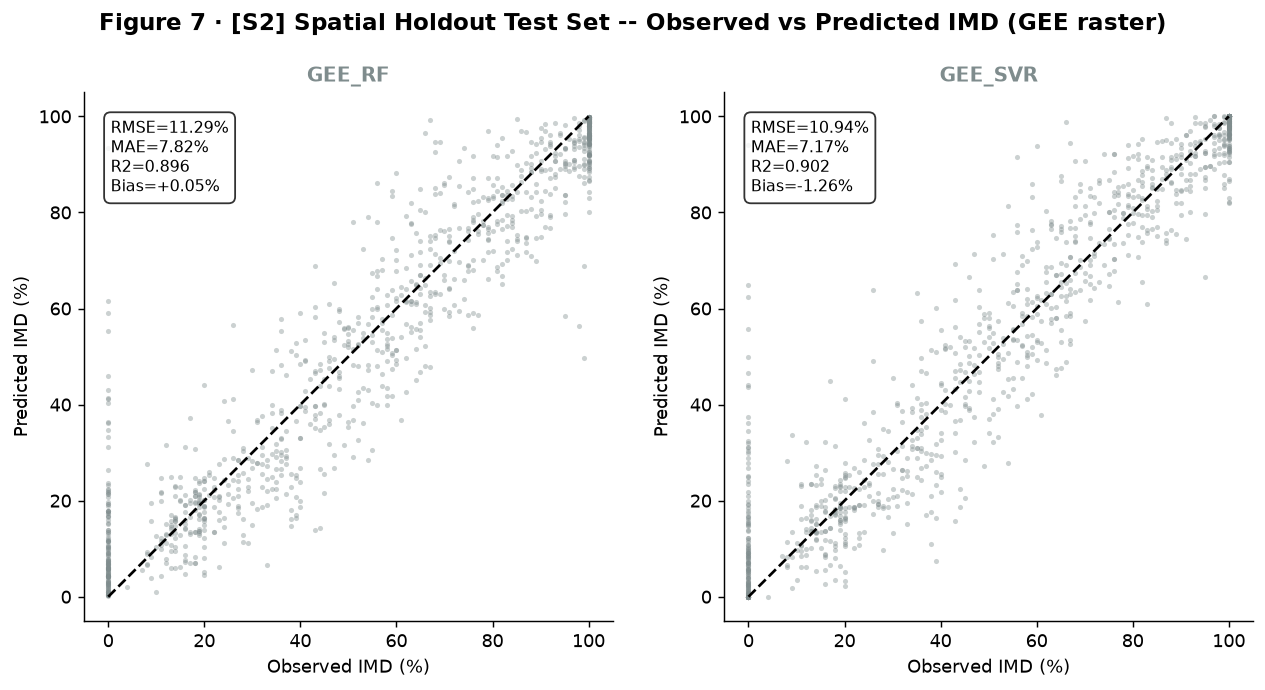

Figure 7 saved.


In [24]:
# Figure 7 -- Holdout scatter plots (GEE rasters)
n_panels = len(holdout_results)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, holdout_results.items()):
    m     = res['metrics']
    yp    = res['y_pred']
    yt    = res['y_true']
    color = MODEL_COLORS.get(name, '#7f8c8d')
    ax.scatter(yt, yp, c=color, s=8, alpha=0.4, linewidths=0)
    ax.plot([0, 100], [0, 100], 'k--', lw=1.5)
    ax.set_xlim(-5, 105); ax.set_ylim(-5, 105)
    ax.set_xlabel('Observed IMD (%)'); ax.set_ylabel('Predicted IMD (%)')
    ax.set_title(name, fontweight='bold', color=color)
    ax.text(0.05, 0.95,
            f'RMSE={m["RMSE"]:.2f}%\nMAE={m["MAE"]:.2f}%\nR2={m["R2"]:.3f}\nBias={m["Bias"]:+.2f}%',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))
    ax.set_aspect('equal')

fig.suptitle('Figure 7 · [S2] Spatial Holdout Test Set -- Observed vs Predicted IMD (GEE raster)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig07_holdout_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')


---
## Cell 17 · Figure A — Scatter + KDE + error boxplot

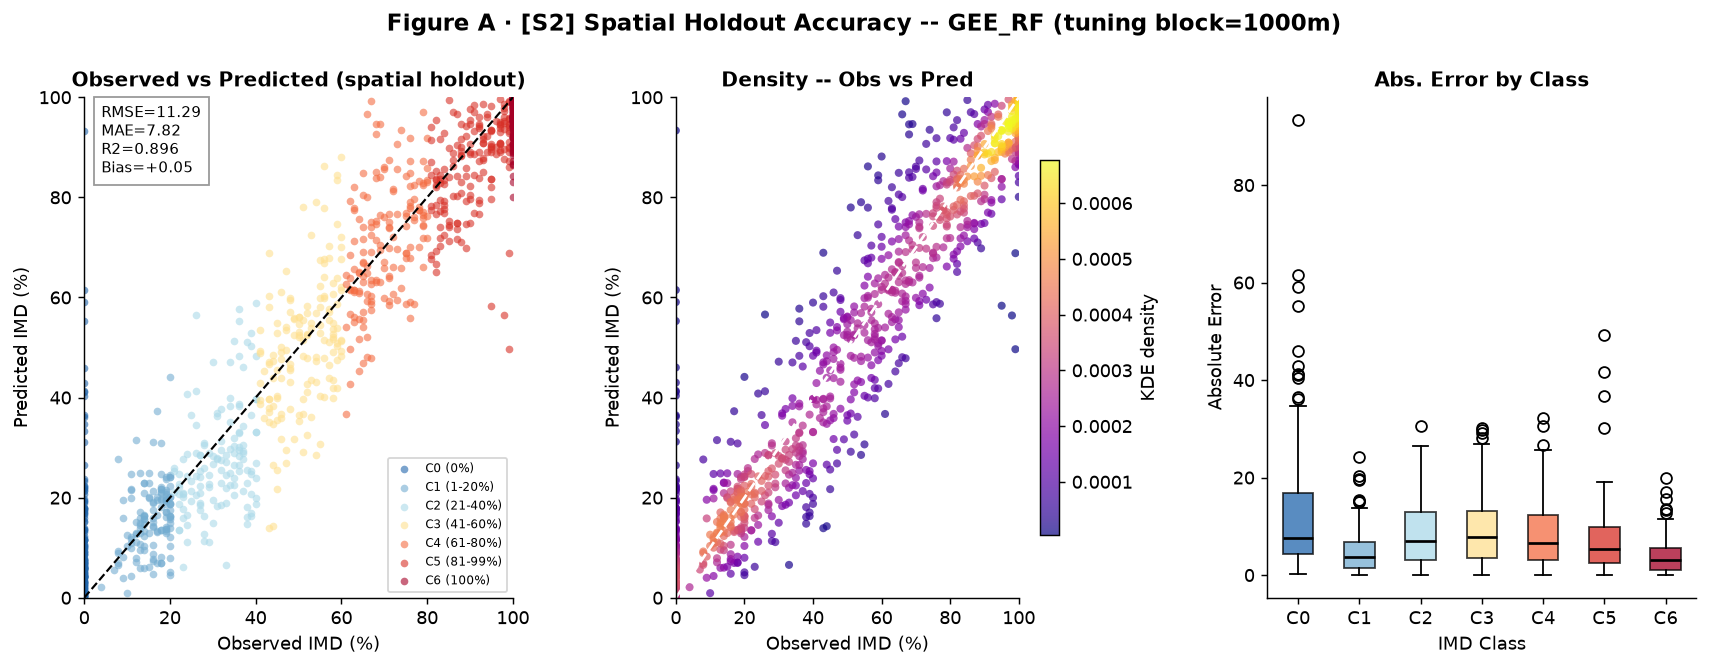

Figure A saved for GEE_RF.


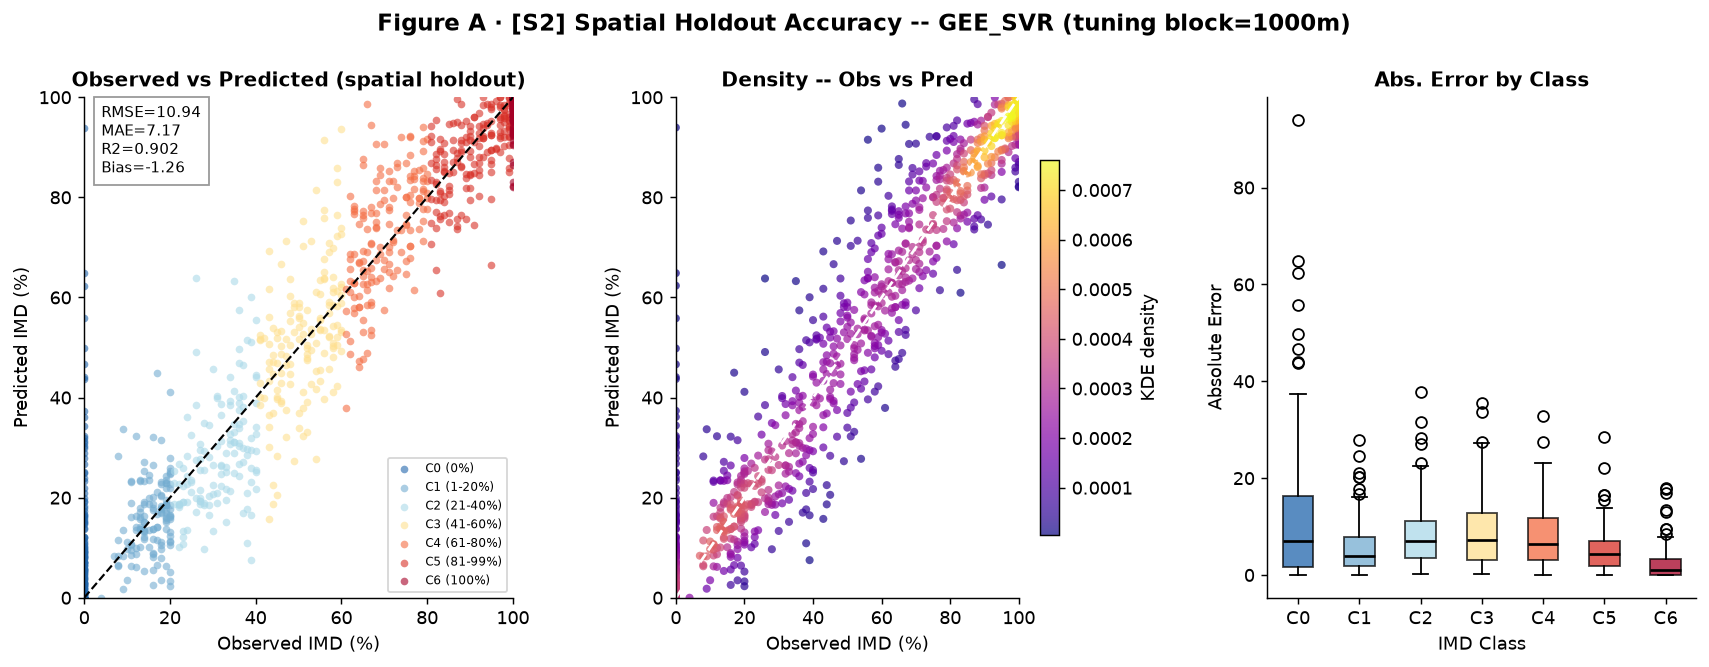

Figure A saved for GEE_SVR.


In [25]:
# Figure A -- Scatter + KDE + error boxplot per GEE model
for name, res in holdout_results.items():
    yt    = res['y_true']
    yp    = res['y_pred']
    ct    = res['cls']
    resid = yt - yp
    rmse  = np.sqrt(mean_squared_error(yt, yp))
    mae   = mean_absolute_error(yt, yp)
    r2    = r2_score(yt, yp)
    bias  = float(np.mean(resid))

    fig = plt.figure(figsize=(16, 5))
    gs  = GridSpec(1, 3, figure=fig, wspace=0.38)

    ax1 = fig.add_subplot(gs[0])
    for c in sorted(np.unique(ct)):
        m = ct == c
        ax1.scatter(yt[m], yp[m], c=CLASS_COLORS[c], s=18, alpha=0.6,
                    linewidths=0, label=CLASS_LABELS[c])
    ax1.plot([0,100],[0,100],'k--',lw=1.2)
    ax1.set_xlim(0,100); ax1.set_ylim(0,100)
    ax1.set_xlabel('Observed IMD (%)'); ax1.set_ylabel('Predicted IMD (%)')
    ax1.set_title('Observed vs Predicted (spatial holdout)', fontweight='bold')
    ax1.legend(fontsize=6.5, framealpha=0.8,loc='lower right')
    ax1.text(0.04, 0.85, f'RMSE={rmse:.2f}\nMAE={mae:.2f}\nR2={r2:.3f}\nBias={bias:+.2f}',
             transform=ax1.transAxes, fontsize=8.5,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='grey'))

    ax2 = fig.add_subplot(gs[1])
    xy  = np.vstack([yt, yp])
    z   = gaussian_kde(xy)(xy)
    idx = z.argsort()
    sc  = ax2.scatter(yt[idx], yp[idx], c=z[idx], cmap='plasma', s=20, alpha=0.7, linewidths=0)
    ax2.plot([0,100],[0,100],'w--',lw=1.5)
    plt.colorbar(sc, ax=ax2, shrink=0.75, label='KDE density')
    ax2.set_xlim(0,100); ax2.set_ylim(0,100)
    ax2.set_xlabel('Observed IMD (%)'); ax2.set_ylabel('Predicted IMD (%)')
    ax2.set_title('Density -- Obs vs Pred', fontweight='bold')

    ax3 = fig.add_subplot(gs[2])
    ucls = sorted(np.unique(ct))
    bp   = ax3.boxplot([np.abs(resid[ct==c]) for c in ucls], patch_artist=True,
                        medianprops={'color':'black','linewidth':1.5})
    for patch, c in zip(bp['boxes'], ucls):
        patch.set_facecolor(CLASS_COLORS[c]); patch.set_alpha(0.75)
    ax3.set_xticks(range(1, len(ucls)+1))
    ax3.set_xticklabels([f'C{c}' for c in ucls])
    ax3.set_xlabel('IMD Class'); ax3.set_ylabel('Absolute Error')
    ax3.set_title('Abs. Error by Class', fontweight='bold')

    fig.suptitle(f'Figure A · [S2] Spatial Holdout Accuracy -- {name} (tuning block={BEST_BLOCK_LABEL})',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.savefig(f'{OUTPUT_DIR}/figA_holdout_accuracy_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure A saved for {name}.')


---
## Cell 18 · Figure B — Model CV comparison bar chart

  Model Comparison -- Spatial CV RMSE (best block)
Model Block  CV RMSE  CV Std
  MLP 1000m   10.696   0.546
  SVR  500m   10.991   0.849
   RF  500m   11.290   0.792


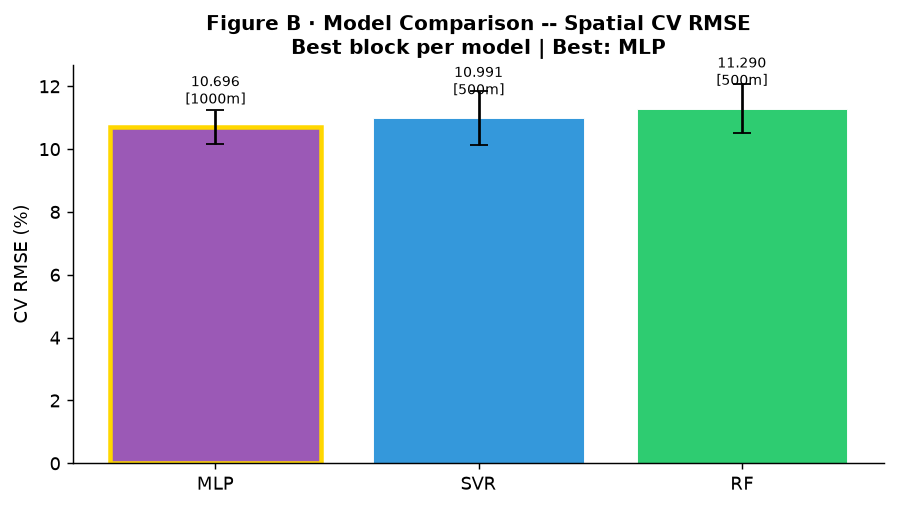

Figure B saved.


In [26]:
# Figure B -- Model CV RMSE comparison (best block per model)
cv_summary = []
for name in tuned_models:
    b  = best_block_per_model[name]
    df = all_results[(name, b)]
    cv_summary.append({'Model': name, 'Block': b,
                        'CV RMSE': round(df['RMSE'].mean(), 3),
                        'CV Std':  round(df['RMSE'].std(), 3)})
cv_df = pd.DataFrame(cv_summary).sort_values('CV RMSE').reset_index(drop=True)

print('===================================================')
print('  Model Comparison -- Spatial CV RMSE (best block)')
print('===================================================')
print(cv_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors_m = [MODEL_COLORS.get(m, '#95a5a6') for m in cv_df['Model']]
bars = ax.bar(cv_df['Model'], cv_df['CV RMSE'],
              yerr=cv_df['CV Std'], color=colors_m,
              edgecolor='white', capsize=5, linewidth=0.5)
bars[0].set_edgecolor('gold'); bars[0].set_linewidth(2.5)
for bar, row in zip(bars, cv_df.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6,
            f'{row._3:.3f}\n[{row.Block}]', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('CV RMSE (%)')
ax.set_title(f'Figure B · Model Comparison -- Spatial CV RMSE\n' +
             f'Best block per model | Best: {cv_df.iloc[0]["Model"]}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figB_model_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure B saved.')


---
## Cell 19 · Figure C — Per-class accuracy


-- Per-Class Accuracy -- GEE_RF --
 Class       Label   N  RMSE   MAE   Bias     R2  Over-pred  Under-pred
     0     C0 (0%) 137 18.85 12.63 -12.63  0.000      100.0         0.0
     1  C1 (1-20%) 136  6.71  4.88  -0.31 -2.243       51.5        48.5
     2 C2 (21-40%) 134 10.79  8.67   3.83 -2.474       29.1        70.9
     3 C3 (41-60%) 151 11.85  9.33   0.91 -3.071       49.0        51.0
     4 C4 (61-80%) 153 10.68  8.30  -0.72 -2.496       50.3        49.7
     5 C5 (81-99%) 166  9.77  6.92   4.42 -1.807       29.5        70.5
     6   C6 (100%) 137  5.55  3.99   3.99  0.000        0.0       100.0


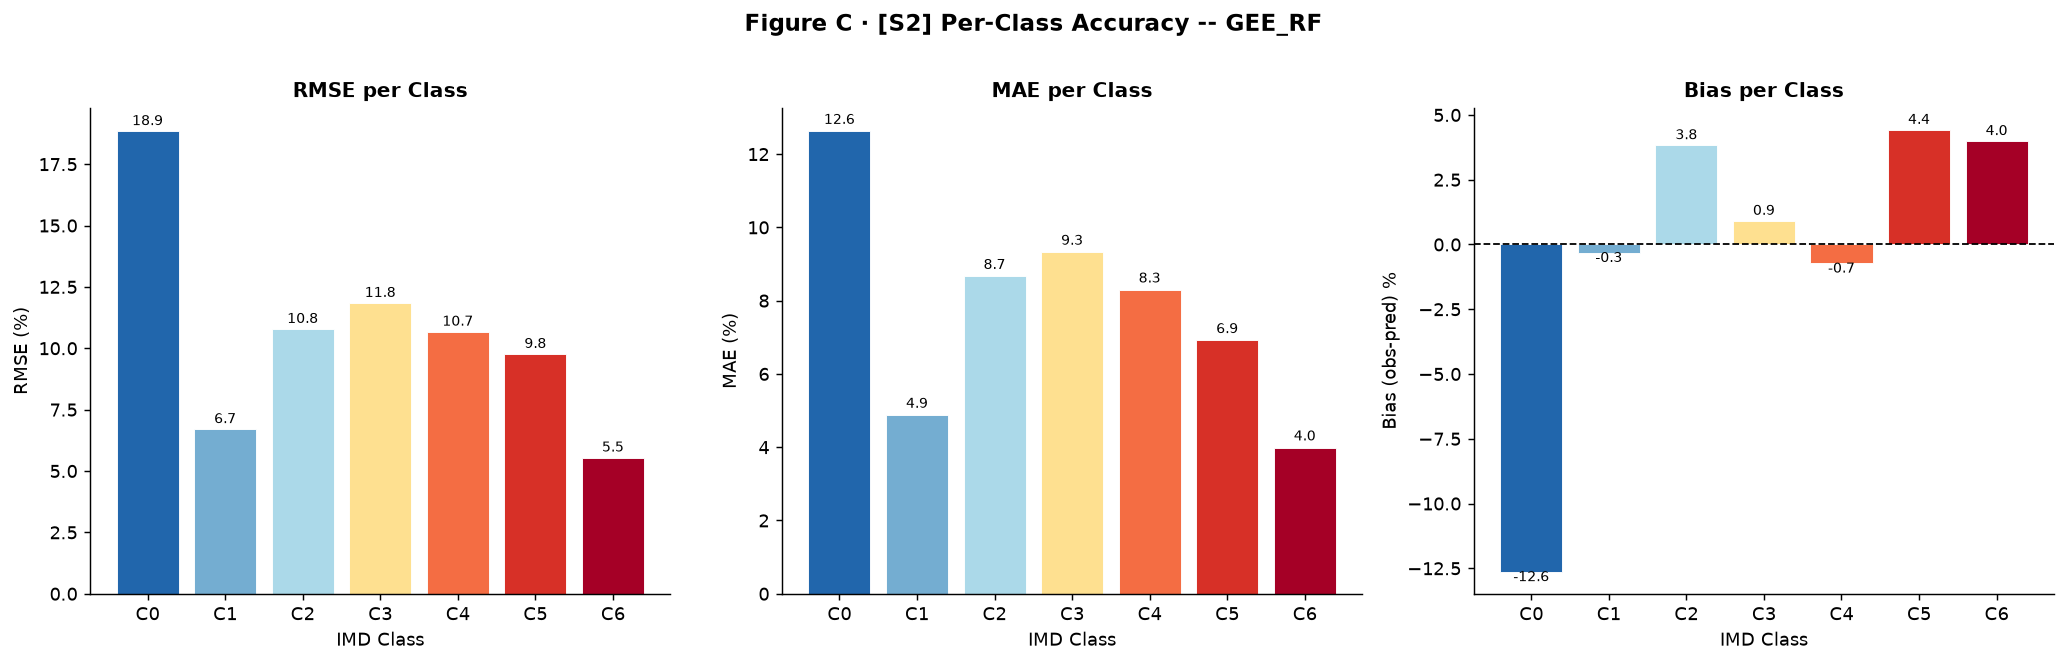

Figure C saved for GEE_RF.

-- Per-Class Accuracy -- GEE_SVR --
 Class       Label   N  RMSE   MAE   Bias     R2  Over-pred  Under-pred
     0     C0 (0%) 137 19.41 12.08 -12.08  0.000       83.9         0.0
     1  C1 (1-20%) 136  7.61  5.49  -0.51 -3.167       47.1        52.9
     2 C2 (21-40%) 134 10.70  8.32   2.75 -2.417       32.8        67.2
     3 C3 (41-60%) 151 11.88  9.13  -0.99 -3.091       53.0        47.0
     4 C4 (61-80%) 153  9.94  7.81  -2.55 -2.026       56.9        43.1
     5 C5 (81-99%) 166  6.78  5.16   1.76 -0.352       41.0        59.0
     6   C6 (100%) 137  4.24  2.36   2.36  0.000        0.0        66.4


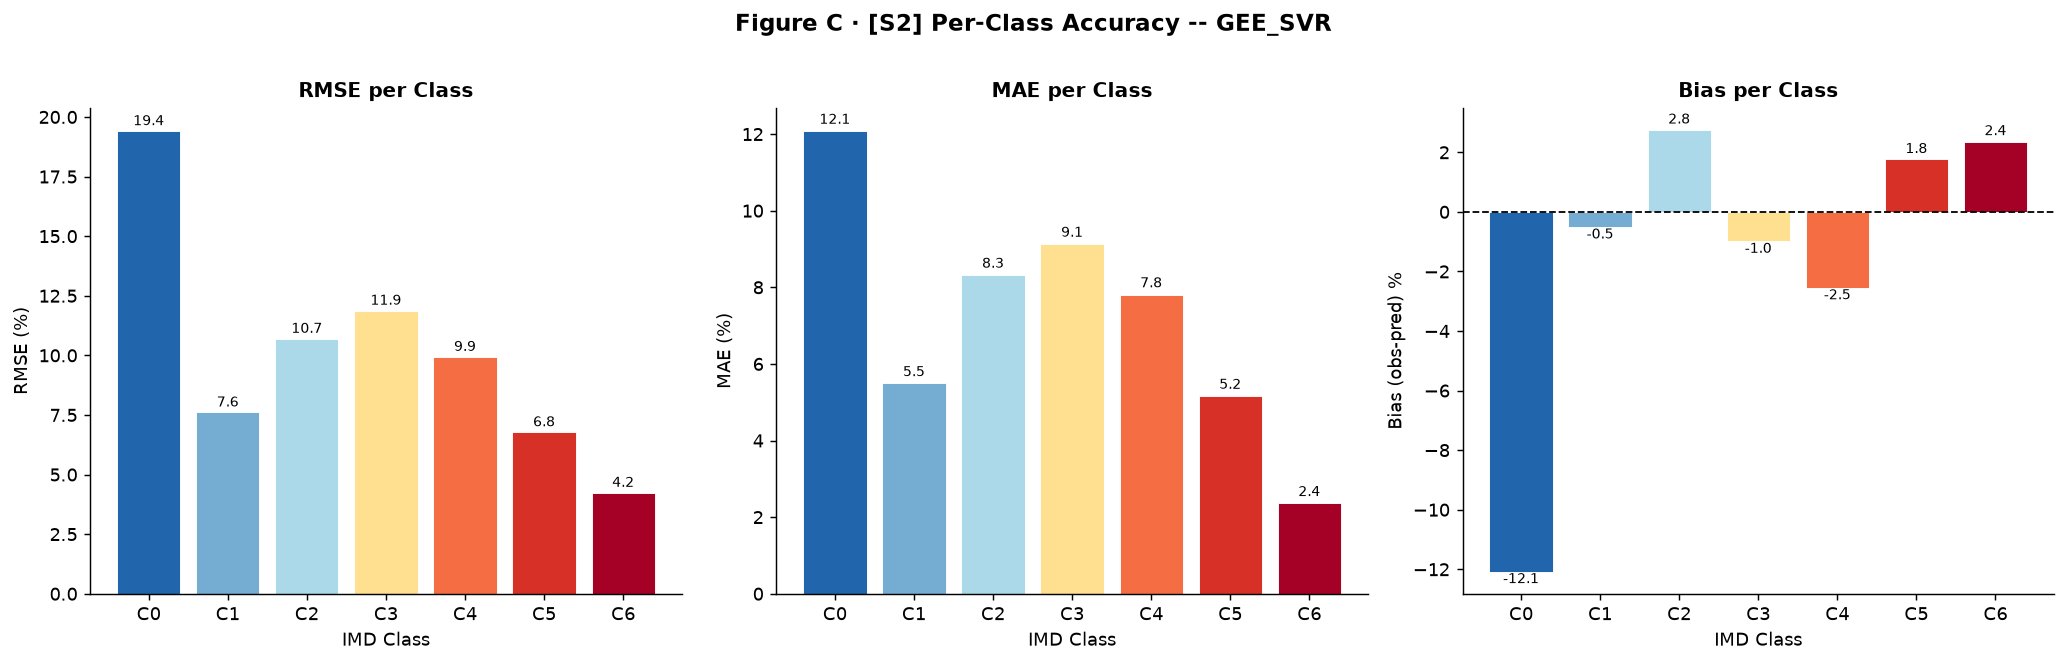

Figure C saved for GEE_SVR.


In [27]:
# Figure C -- Per-class accuracy
for name, res in holdout_results.items():
    yt    = res['y_true']
    yp    = res['y_pred']
    ct    = res['cls']

    class_metrics = []
    for c in range(N_CLASSES):
        m = ct == c
        if m.sum() < 2:
            continue
        obs_c = yt[m]; pred_c = yp[m]; res_c = obs_c - pred_c
        class_metrics.append({
            'Class':      c, 'Label': CLASS_LABELS[c], 'N': int(m.sum()),
            'RMSE':       round(float(np.sqrt(mean_squared_error(obs_c, pred_c))), 2),
            'MAE':        round(float(mean_absolute_error(obs_c, pred_c)), 2),
            'Bias':       round(float(np.mean(res_c)), 2),
            'R2':         round(float(r2_score(obs_c, pred_c)), 3) if m.sum() > 1 else np.nan,
            'Over-pred':  round(float((res_c < 0).mean() * 100), 1),
            'Under-pred': round(float((res_c > 0).mean() * 100), 1),
        })
    cls_df = pd.DataFrame(class_metrics)
    cls_df.to_csv(f'{OUTPUT_DIR}/perclass_metrics_{name}.csv', index=False)
    print(f'\n-- Per-Class Accuracy -- {name} --')
    print(cls_df.to_string(index=False))

    fig, axes_c = plt.subplots(1, 3, figsize=(16, 5))
    for ax, metric, ylabel in zip(axes_c, ['RMSE','MAE','Bias'],
                                   ['RMSE (%)','MAE (%)','Bias (obs-pred) %']):
        colors_c = [CLASS_COLORS[c] for c in cls_df['Class']]
        bars = ax.bar(cls_df['Class'], cls_df[metric], color=colors_c, edgecolor='white', lw=0.5)
        if metric == 'Bias':
            ax.axhline(0, color='black', lw=1, ls='--')
        for bar, val in zip(bars, cls_df[metric]):
            ypos = bar.get_height() + (0.1 if val >= 0 else -0.5)
            ax.text(bar.get_x()+bar.get_width()/2, ypos, f'{val:.1f}',
                    ha='center', va='bottom', fontsize=8)
        ax.set_xticks(cls_df['Class'])
        ax.set_xticklabels([f'C{c}' for c in cls_df['Class']])
        ax.set_xlabel('IMD Class'); ax.set_ylabel(ylabel)
        ax.set_title(f'{metric} per Class', fontweight='bold')
    fig.suptitle(f'Figure C · [S2] Per-Class Accuracy -- {name}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/figC_perclass_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure C saved for {name}.')


---
## Cell 20 · Figure D — Feature importance (RF)

**Reading this under a wide composite.** `percentile` and `stack` produce
strongly collinear features — one band's percentiles (`B11_p25`, `B11_p50`,
`B11_p75`, …) are near-duplicates of one another, as is the same band repeated
across dates. Widening `PERCENTILES` deepens this: adding `p10`/`p90` adds two
more columns per band that correlate strongly with the ones already there.
Permutation importance
splits credit arbitrarily among correlated columns: permuting one of three
near-identical features barely moves the score because the other two still
carry the signal, so every member of the group looks unimportant. Read the
grouped summary printed below the figure rather than the individual bars.

Computing permutation importance...


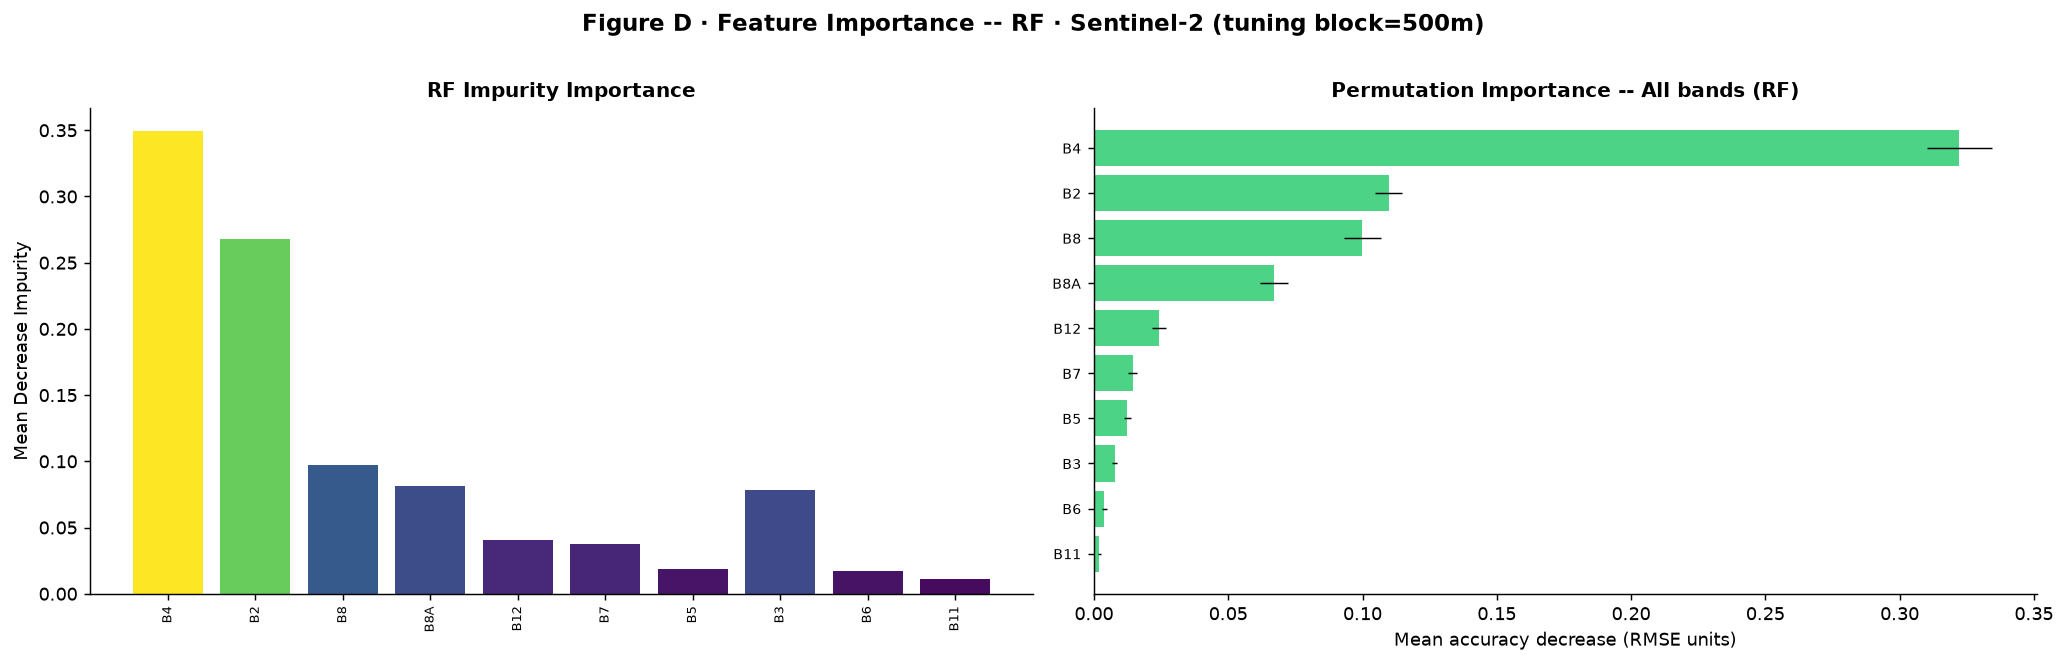

Figure D saved.


In [28]:
# Figure D -- Permutation importance (RF)
name = 'GEE_RF'
if name not in holdout_results:
    print(f'{name} not in holdout_results -- skipping.')
else:
    yt = holdout_results[name]['y_true']
    # NB: renamed from `valid_mask` -- that name is the s2_utils cloud-mask fn
    valid_pix    = ~np.isnan(np.clip(sample_raster_at_points(RF_RASTER_PATH, gdf_test), 0, 100))
    X_test_valid = X_test[valid_pix]

    rf_model = tuned_models['RF']
    print('Computing permutation importance...')
    perm     = permutation_importance(rf_model, X_test_valid, yt,
                                      n_repeats=10, random_state=RANDOM_STATE, n_jobs=N_JOBS)
    sort_idx = np.argsort(perm.importances_mean)[::-1]

    fig, axes_d = plt.subplots(1, 2, figsize=(16, 5))
    ax = axes_d[0]
    imp = rf_model.feature_importances_
    ax.bar(range(len(band_names)), imp[sort_idx],
           color=plt.cm.viridis(imp[sort_idx]/imp.max()), edgecolor='none')
    ax.set_xticks(range(len(band_names)))
    ax.set_xticklabels([band_names[i] for i in sort_idx], rotation=90, fontsize=7)
    ax.set_ylabel('Mean Decrease Impurity')
    ax.set_title('RF Impurity Importance', fontweight='bold')

    ax = axes_d[1]
    # Only 10 S2 bands, so show all of them -- range(20) against a 10-element
    # slice would mismatch set_yticks and raise.
    n_top = min(20, len(band_names))
    top_n = sort_idx[:n_top]
    ax.barh(range(n_top), perm.importances_mean[top_n][::-1],
            xerr=perm.importances_std[top_n][::-1],
            color=MODEL_COLORS['RF'], alpha=0.85, edgecolor='none',
            error_kw={'linewidth': 0.8, 'color': 'black'})
    ax.set_yticks(range(n_top))
    ax.set_yticklabels([band_names[i] for i in top_n[::-1]], fontsize=8)
    ax.set_xlabel('Mean accuracy decrease (RMSE units)')
    _ttl = 'All bands' if n_top == len(band_names) else f'Top {n_top}'
    ax.set_title(f'Permutation Importance -- {_ttl} (RF)', fontweight='bold')

    fig.suptitle(f'Figure D · Feature Importance -- RF · Sentinel-2 (tuning block={best_block_per_model["RF"]})',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/figD_importance_RF.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure D saved.')

# ── Grouped importance -- the readable view when features are collinear ──────
# Permutation importance is unreliable for near-duplicate columns (see the
# markdown above), so aggregate impurity importance two ways: by spectral band
# (is SWIR still doing the work?) and by the composite's own axis -- percentile
# or date -- which is the question the method comparison actually asks.
if name in holdout_results and COMPOSITE_METHOD != 'median':
    imp_s = pd.Series(rf_model.feature_importances_, index=band_names)

    by_band = imp_s.groupby([b.split('_')[0] for b in band_names]).sum()
    print('\nImpurity importance by spectral band:')
    for b, v in by_band.sort_values(ascending=False).items():
        print(f'  {b:<5} {v:.4f}  {"#" * int(round(v * 100))}')

    axis = 'percentile' if COMPOSITE_METHOD == 'percentile' else 'date'
    by_axis = imp_s.groupby([b.split('_')[1] for b in band_names]).sum()
    print(f'\nImpurity importance by {axis}:')
    for k, v in by_axis.sort_index().items():
        lbl = k if axis == 'percentile' else f'{k} ({SELECTED_DATES[int(k[1:])]})'
        print(f'  {lbl:<18} {v:.4f}  {"#" * int(round(v * 100))}')



---
## Cell 21 · Figure E — Raster comparison map

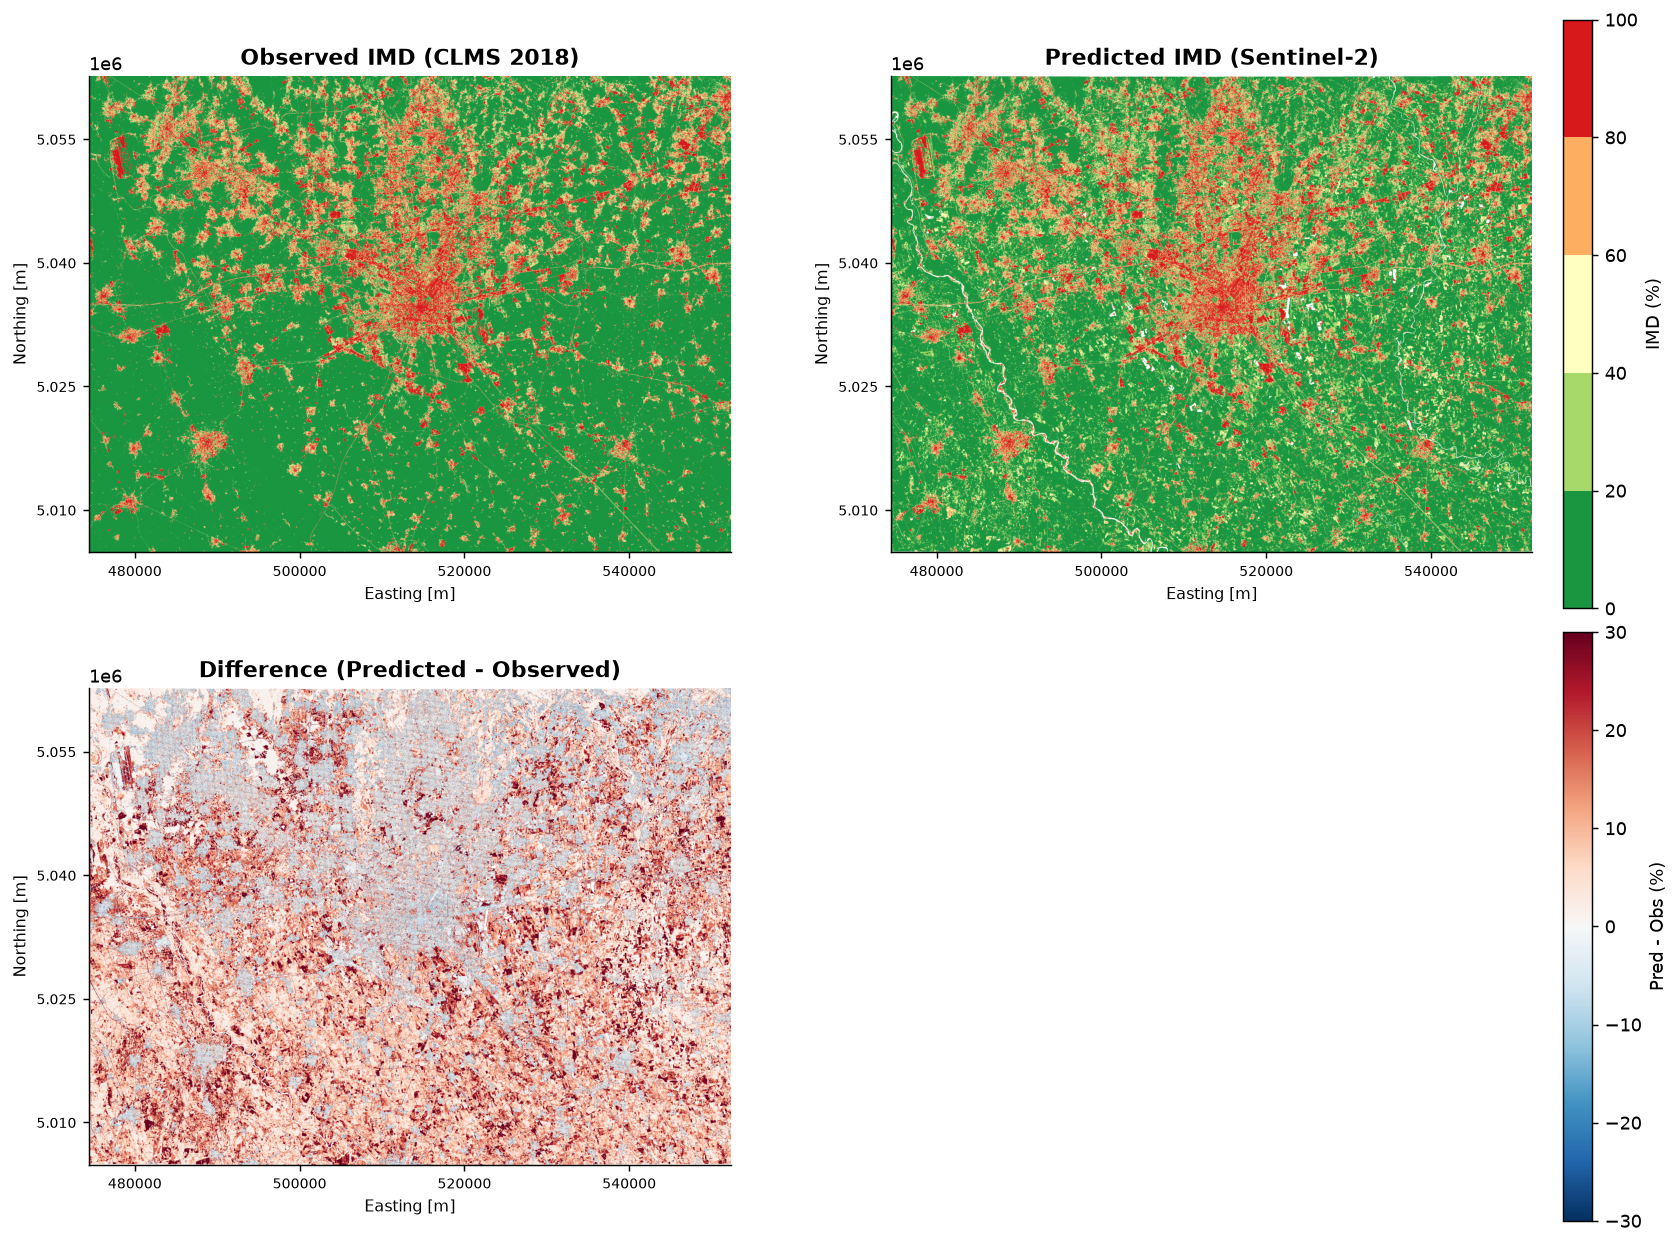

Figure E saved.


In [29]:
# Figure E -- Raster comparison
DISPLAY_SCALE = 2
IMD_OBS_PATH  = 'data\IMD_2018_CLMS_UTM32N.tif'
IMD_PRED_PATH = RF_RASTER_PATH

imd_obs  = rxr.open_rasterio(IMD_OBS_PATH,  masked=False).squeeze('band', drop=True)[::DISPLAY_SCALE, ::DISPLAY_SCALE]
imd_pred = rxr.open_rasterio(IMD_PRED_PATH, masked=False).squeeze('band', drop=True)[::DISPLAY_SCALE, ::DISPLAY_SCALE]
if imd_pred.rio.crs != imd_obs.rio.crs or imd_pred.shape != imd_obs.shape:
    imd_pred = imd_pred.rio.reproject_match(imd_obs)
imd_diff = imd_pred - imd_obs
imd_cmap = ListedColormap(['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c'])

def imshow_aspect(ax, da, **kw):
    b  = da.rio.bounds()
    im = ax.imshow(da.values, extent=(b[0], b[2], b[1], b[3]), **kw)
    ax.set_aspect('equal')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.tick_params(axis='both', labelsize=8)
    ax.set_xlabel('Easting [m]', fontsize=9); ax.set_ylabel('Northing [m]', fontsize=9)
    return im

fig, axes_e = plt.subplots(2, 2, figsize=(15, 12), gridspec_kw={'wspace': 0.25, 'hspace': 0.04})
im1 = imshow_aspect(axes_e[0,0], imd_obs,  cmap=imd_cmap, vmin=0, vmax=100)
axes_e[0,0].set_title('Observed IMD (CLMS 2018)', fontweight='bold', fontsize=12)
im2 = imshow_aspect(axes_e[0,1], imd_pred, cmap=imd_cmap, vmin=0, vmax=100)
axes_e[0,1].set_title('Predicted IMD (Sentinel-2)', fontweight='bold', fontsize=12)
im3 = imshow_aspect(axes_e[1,0], imd_diff, cmap='RdBu_r', vmin=-30, vmax=30)
axes_e[1,0].set_title('Difference (Predicted - Observed)', fontweight='bold', fontsize=12)
axes_e[1,1].axis('off')

fig.colorbar(im1, ax=axes_e[0,:], orientation='vertical', fraction=0.025, pad=0.02, label='IMD (%)')
fig.colorbar(im3, ax=axes_e[1,:], orientation='vertical', fraction=0.025, pad=0.02, label='Pred - Obs (%)')
# fig.suptitle(f'Figure E · IMD Observed vs Predicted vs Difference -- Milan\n' +
#             f'RF + AEF | tuning block={best_block_per_model["RF"]} | spatial test pts shown',
#             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(f'{OUTPUT_DIR}/figE_raster_comparison_1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure E saved.')

In [ ]:
# (Removed) The one-off CRS repair for data/IMD_2018_CLMS.tif lives in
# notebook 01 and has already been applied -- data/IMD_2018_CLMS_fixed.tif
# exists. Re-running it here would be a no-op.


---
## Cell 22 · Final summary

In [30]:
print('='*75)
print('   FINAL SUMMARY -- SPATIALLY STRATIFIED DESIGN')
print('='*75)

print(f'\n0. SPATIAL TRAIN/TEST SPLIT ({SPLIT_BLOCK_M}m blocks, {BUFFER_M}m buffer):')
print(f'   Train: {len(train_idx)} pts | Test: {len(test_idx)} pts')
print(f'   Test fraction: {100*len(test_idx)/(len(train_idx)+len(test_idx)):.1f}%')

print('\n1. HYPERPARAMETER TUNING (spatial block CV on training set):')
for name in tuned_models:
    b    = best_block_per_model[name]
    rmse = tune_df[(tune_df['Model']==name) & (tune_df['Block']==b)]['CV_RMSE'].values[0]
    print(f'  {name:<8}: best block={b}  CV RMSE={rmse:.3f}')

print(f'\n2. SPATIAL CV EVALUATION (buffer={BUFFER_M}m, {N_FOLDS}-fold, training set only):')
pivot = summary_df.pivot_table(index='Model', columns='CV_method', values='RMSE_mean')[CV_LABELS]
print(pivot.round(2).to_string())

print(f'\n3. SPATIAL HOLDOUT TEST SET:')
print(holdout_df.to_string(index=False))

print(f'\n* Best model: {BEST_MODEL_NAME} @ {BEST_BLOCK_LABEL}')

print('\n4. SPATIAL AUTOCORRELATION INFLATION:')
for name in tuned_models:
    b   = best_block_per_model[name]
    rnd = all_results[(name, 'Random')]['RMSE'].mean()
    sp  = all_results[(name, b)]['RMSE'].mean()
    print(f'  {name}: {sp-rnd:+.2f}% RMSE ({100*(sp-rnd)/rnd:+.1f}% relative) at {b} blocks')

print('\nOutputs:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'  {f:<50} {sz/1024:>8.1f} kB')
print('='*75)

   FINAL SUMMARY -- SPATIALLY STRATIFIED DESIGN

0. SPATIAL TRAIN/TEST SPLIT (1000m blocks, 250m buffer):
   Train: 2449 pts | Test: 1014 pts
   Test fraction: 29.3%

1. HYPERPARAMETER TUNING (spatial block CV on training set):
  RF      : best block=500m  CV RMSE=11.094
  SVR     : best block=500m  CV RMSE=10.849
  MLP     : best block=1000m  CV RMSE=10.543

2. SPATIAL CV EVALUATION (buffer=250m, 5-fold, training set only):
CV_method  Random   500m  1000m  2000m
Model                                 
MLP         10.63  10.75  10.70  10.64
RF          11.15  11.29  11.23  11.20
SVR         10.83  10.99  10.95  10.91

3. SPATIAL HOLDOUT TEST SET:
  Model   RMSE   MAE    R2   Bias
 GEE_RF 11.285 7.820 0.896  0.046
GEE_SVR 10.939 7.171 0.902 -1.263

* Best model: MLP @ 1000m

4. SPATIAL AUTOCORRELATION INFLATION:
  RF: +0.14% RMSE (+1.3% relative) at 500m blocks
  SVR: +0.16% RMSE (+1.5% relative) at 500m blocks
  MLP: +0.07% RMSE (+0.6% relative) at 1000m blocks

Outputs:
  IMD_predicted